In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
sys.path.append("/extdata4/baeklab/Hyeonseo/m6A/modformer")
from utils.utils import printmessage
import glob
import tqdm

In [3]:
ON0092_df = pd.read_pickle(f"/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0092/ON0092/result/dorado-070/intermediates/segmented_tokenized/signal_analysis/sampled.pkl")
ON0093_df = pd.read_pickle(f"/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0093/ON0093/result/dorado-070/intermediates/segmented_tokenized/signal_analysis/sampled.pkl")
ON0096_df = pd.read_pickle(f"/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0096/result/dorado-070/intermediates/segmented_tokenized/signal_analysis/sampled.pkl")
ON0098_df = pd.read_pickle(f"/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0098/result/dorado-070/intermediates/segmented_tokenized/signal_analysis/sampled.pkl")
ON0099_df = pd.read_pickle(f"/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0099/result/dorado-070/intermediates/segmented_tokenized/signal_analysis/sampled.pkl")
df_dict = {"ON0092": ON0092_df, "ON0093": ON0093_df, "ON0096": ON0096_df, "ON0098": ON0098_df, "ON0099": ON0099_df}


In [4]:
print(len(ON0092_df.iloc[0]["signal_mean"]))
print(len(ON0092_df.iloc[0]["bq"]))

27
21


In [35]:
def mean_phred(phred):
    if not isinstance(phred, np.ndarray):
        phred = np.array(phred, dtype=int)
    else:
        phred = phred.astype(int)
    ## When averaging PHRED scores, note that the PHRED score is logarithmically scaled.
    return -10 * np.log10(np.mean(10 ** (-phred / 10)))


In [6]:
for df in df_dict.values():
    df["7mer"] = df["motif"].apply(lambda x: x[7:14])
    df["9mer"] = df["motif"].apply(lambda x: x[6:15])
    df["11mer"] = df["motif"].apply(lambda x: x[5:16])

In [36]:
## Groupby 5mer and calculate mean signal
def get_motif_signal(df_dict, key = "5mer"):
    motif_dict = {}
    for k in df_dict.keys():
        df = df_dict[k]
        df["bq_centre"] = df["bq"].apply(lambda x: x[10])
        df["signal_centre"] = df["signal_mean"].apply(lambda x: x[13])
        df["bq_avg"] = df["bq"].apply(lambda x: mean_phred(x))
        df["signal_avg"] = df["signal_mean"].apply(lambda x: np.mean(x[3:-3]))
        df["signal_5mer"] = df["signal_mean"].apply(lambda x: np.mean(x[11:-11]))
        df["signal_7mer"] = df["signal_mean"].apply(lambda x: np.mean(x[10:-10]))
        df["signal_9mer"] = df["signal_mean"].apply(lambda x: np.mean(x[9:-9]))
        motif_df = df[["bq_centre", "signal_centre", "bq_avg", "signal_avg", key]].groupby(key).mean()
        motif_dict[k] = motif_df
    return motif_dict

In [37]:
dict_5mer = get_motif_signal(df_dict, key = "5mer")
dict_7mer = get_motif_signal(df_dict, key = "7mer")
dict_9mer = get_motif_signal(df_dict, key = "9mer")

In [19]:
plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

In [47]:
## Plot scatter : ON0092 vs. ON0096

from scipy import stats

def plot(df_dict, k1, k2, bq_feature = "bq_avg", signal_feature = "signal_avg", x_label = None, y_label = None):
    fig, ax = plt.subplots(1,2, figsize = (20,10))
    merged_df = pd.merge(df_dict[k1], df_dict[k2], how = "inner", left_index = True, right_index = True).dropna()
    bq_df = merged_df[[f"{bq_feature}_x", f"{bq_feature}_y"]]
    signal_df = merged_df[[f"{signal_feature}_x", f"{signal_feature}_y"]]
    bq_df.columns = [k1, k2]
    signal_df.columns = [k1, k2]

    sns.scatterplot(x = k1, y = k2, data = bq_df, ax = ax[0])
    r2 = stats.pearsonr(bq_df[k1], bq_df[k2])[0]**2
    rho2 = stats.spearmanr(bq_df[k1], bq_df[k2])[0]**2
    ax[0].text(0.1, 0.9, f"R2: {r2:.2f}\nRho2: {rho2:.2f}", transform=ax[0].transAxes)
    ax[0].set_title("BQ")
    min_val = min(np.min(bq_df[k1]), np.min(bq_df[k2]))
    max_val = max(np.max(bq_df[k1]), np.max(bq_df[k2]))
    ax[0].set_xlim(min_val, max_val)
    ax[0].set_ylim(min_val, max_val)
    ax[0].aspect = 1
    ax[0].set_xlabel(x_label if x_label else k1)
    ax[0].set_ylabel(y_label if y_label else k2)


    sns.scatterplot(x = k1, y = k2, data = signal_df, ax = ax[1])
    r2 = stats.pearsonr(signal_df[k1], signal_df[k2])[0]**2
    rho2 = stats.spearmanr(signal_df[k1], signal_df[k2])[0]**2
    ax[1].text(0.1, 0.9, f"R2: {r2:.2f}\nRho2: {rho2:.2f}", transform=ax[1].transAxes)
    ax[1].set_title("Signal")
    min_val = min(np.min(signal_df[k1]), np.min(signal_df[k2]))
    max_val = max(np.max(signal_df[k1]), np.max(signal_df[k2]))
    ax[1].set_xlim(min_val, max_val)
    ax[1].set_ylim(min_val, max_val)
    ax[1].aspect = 1
    ax[1].set_xlabel(x_label if x_label else k1)
    ax[1].set_ylabel(y_label if y_label else k2)

    plt.savefig(f"/extdata4/baeklab/Hyeonseo/m6A/poster/{k1}_{k2}.pdf")
    plt.show()

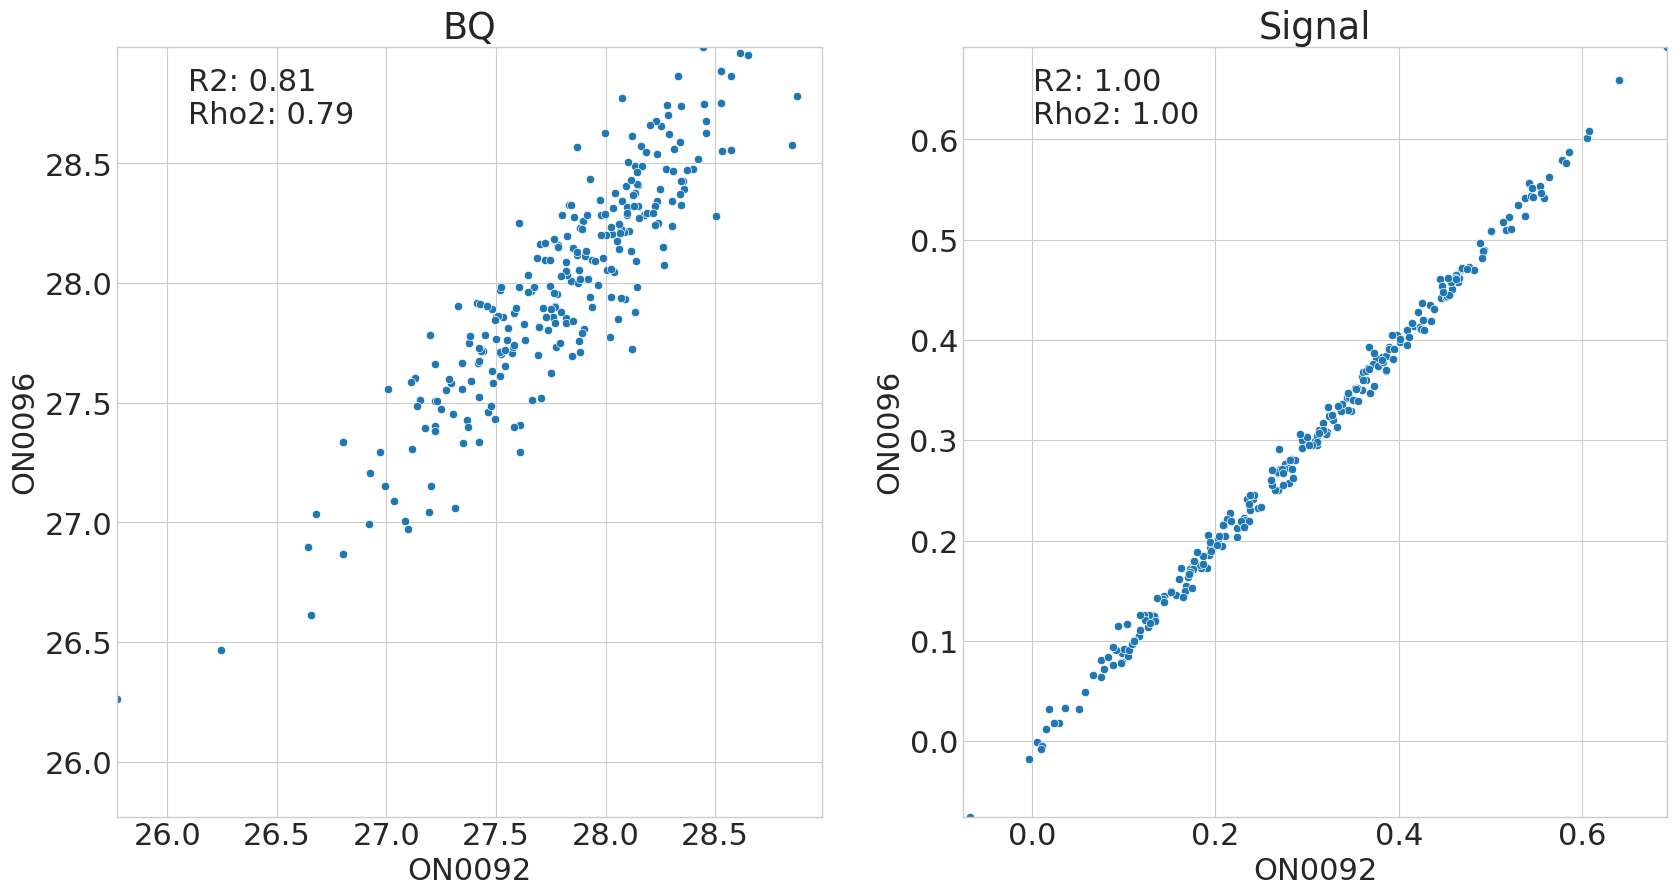

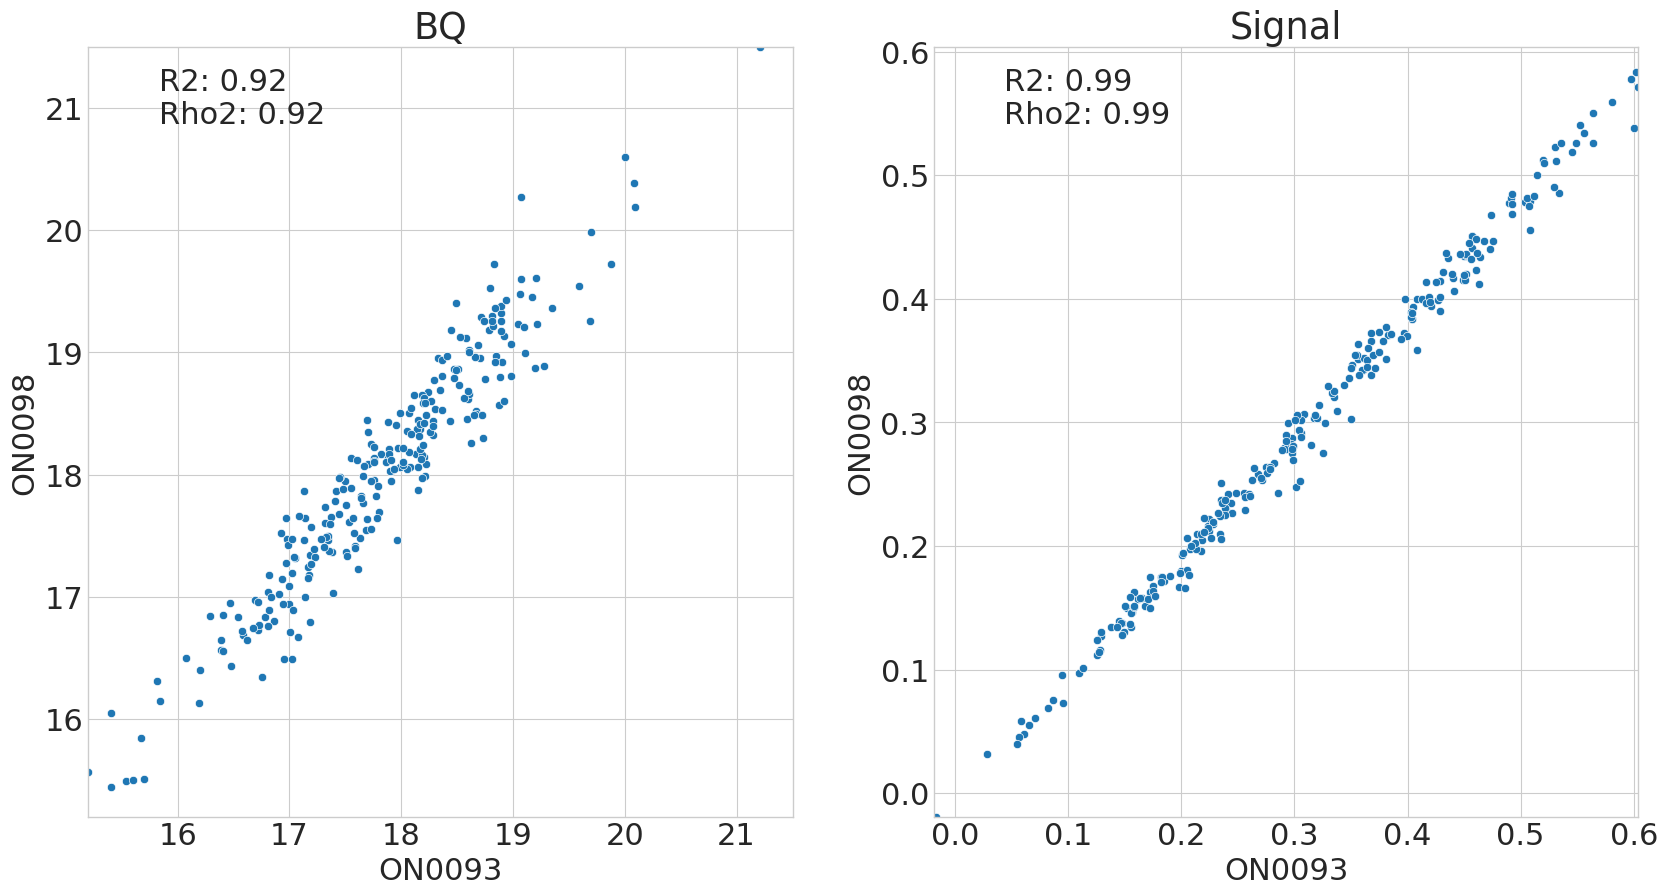

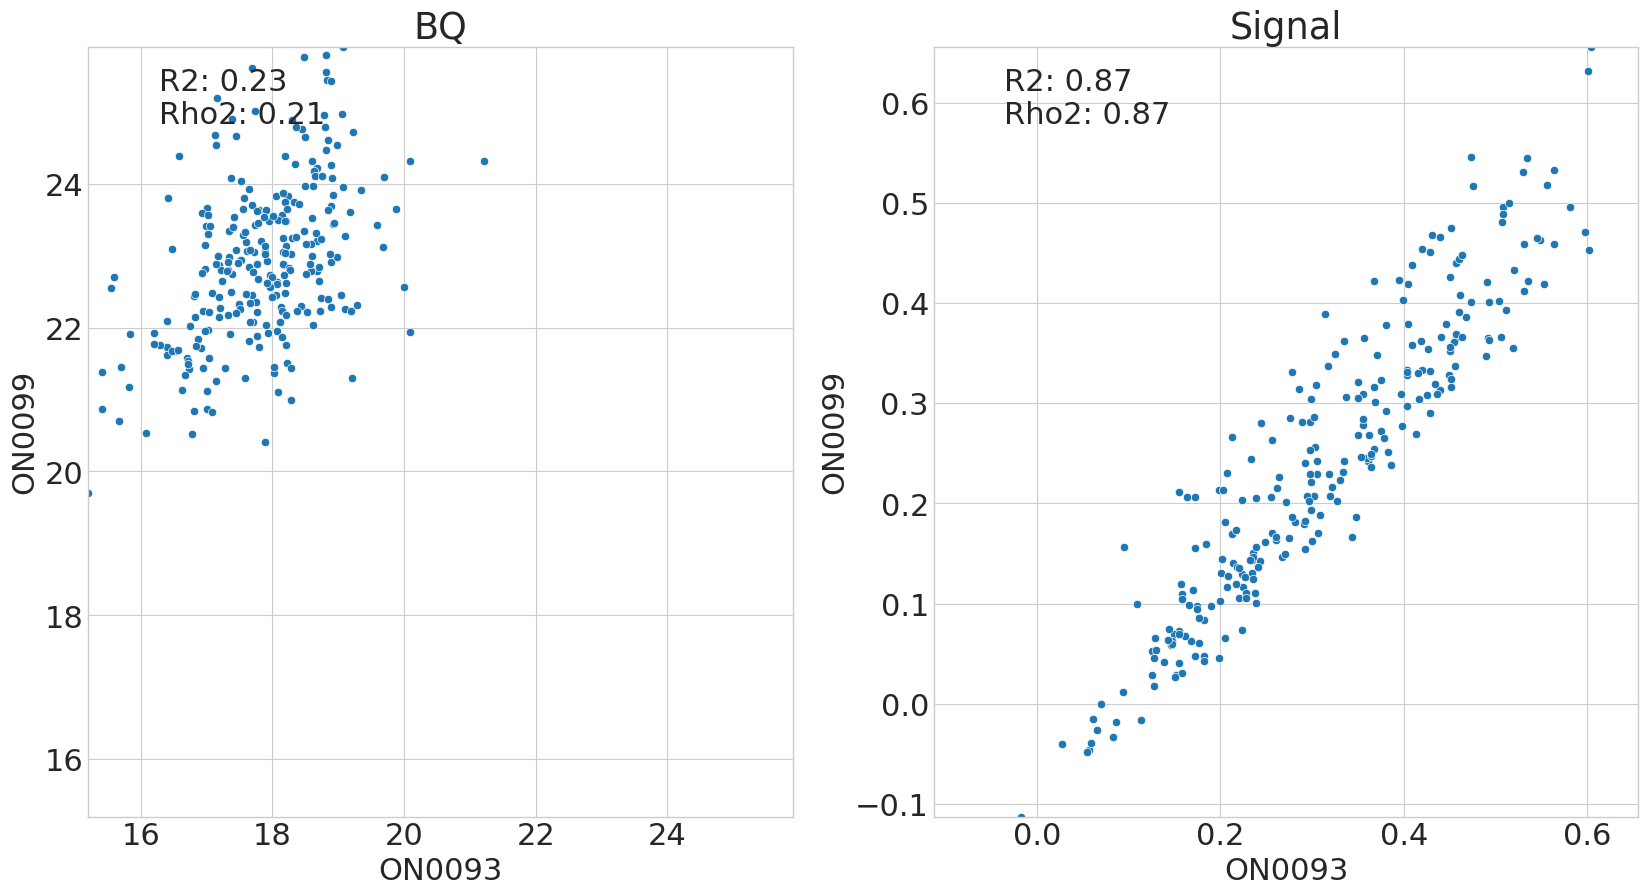

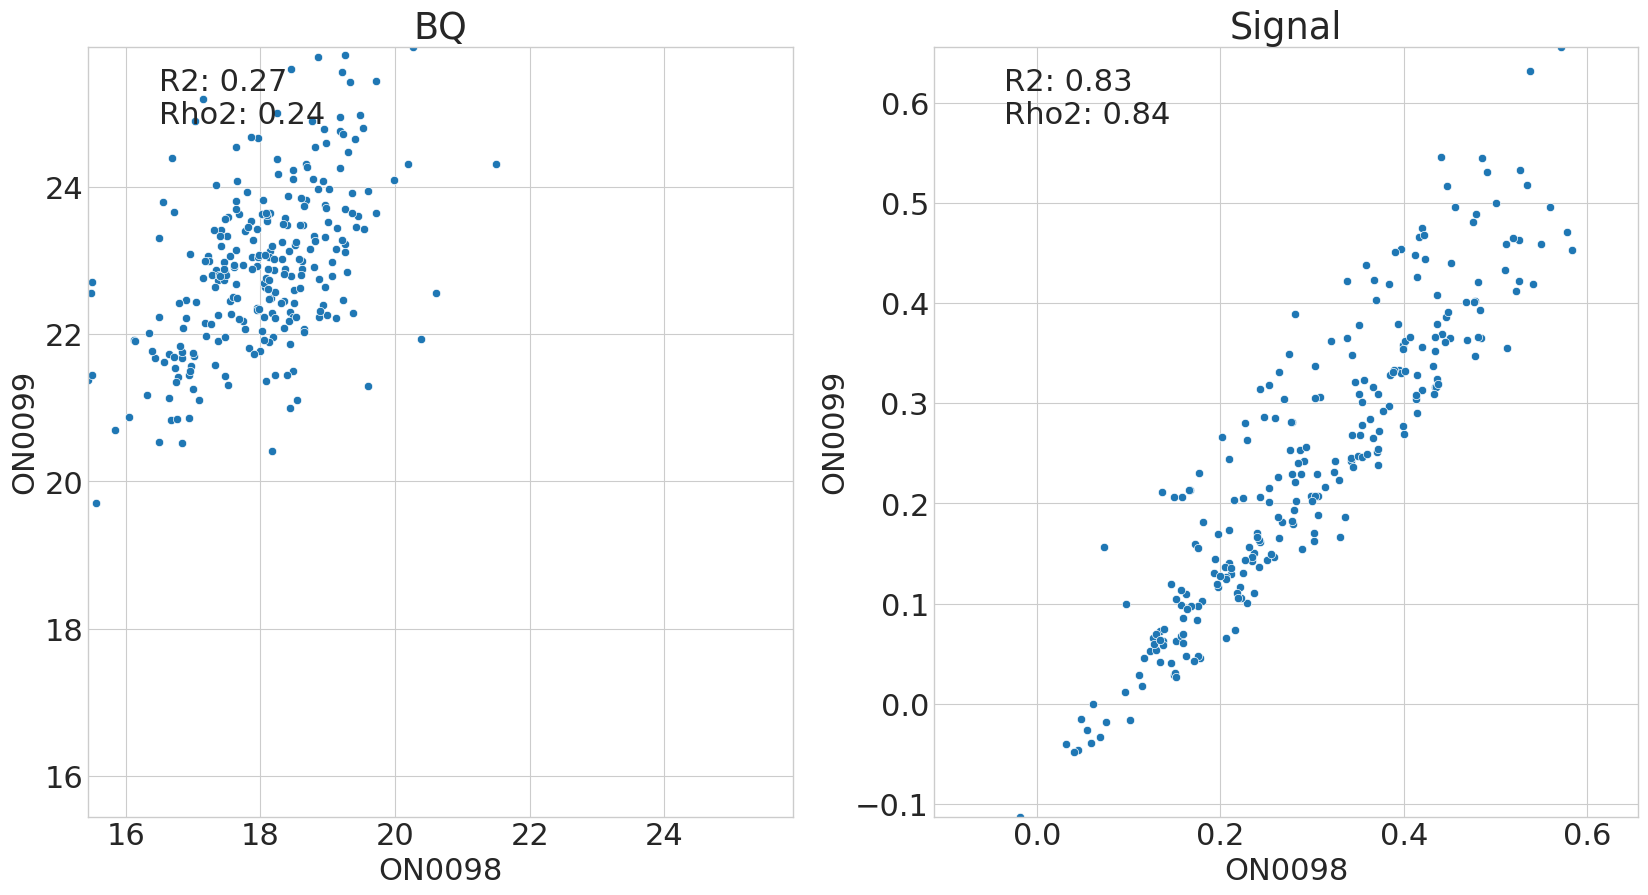

In [38]:
plot(dict_5mer, "ON0092", "ON0096")
plot(dict_5mer, "ON0093", "ON0098")
plot(dict_5mer, "ON0093", "ON0099")
plot(dict_5mer, "ON0098", "ON0099")

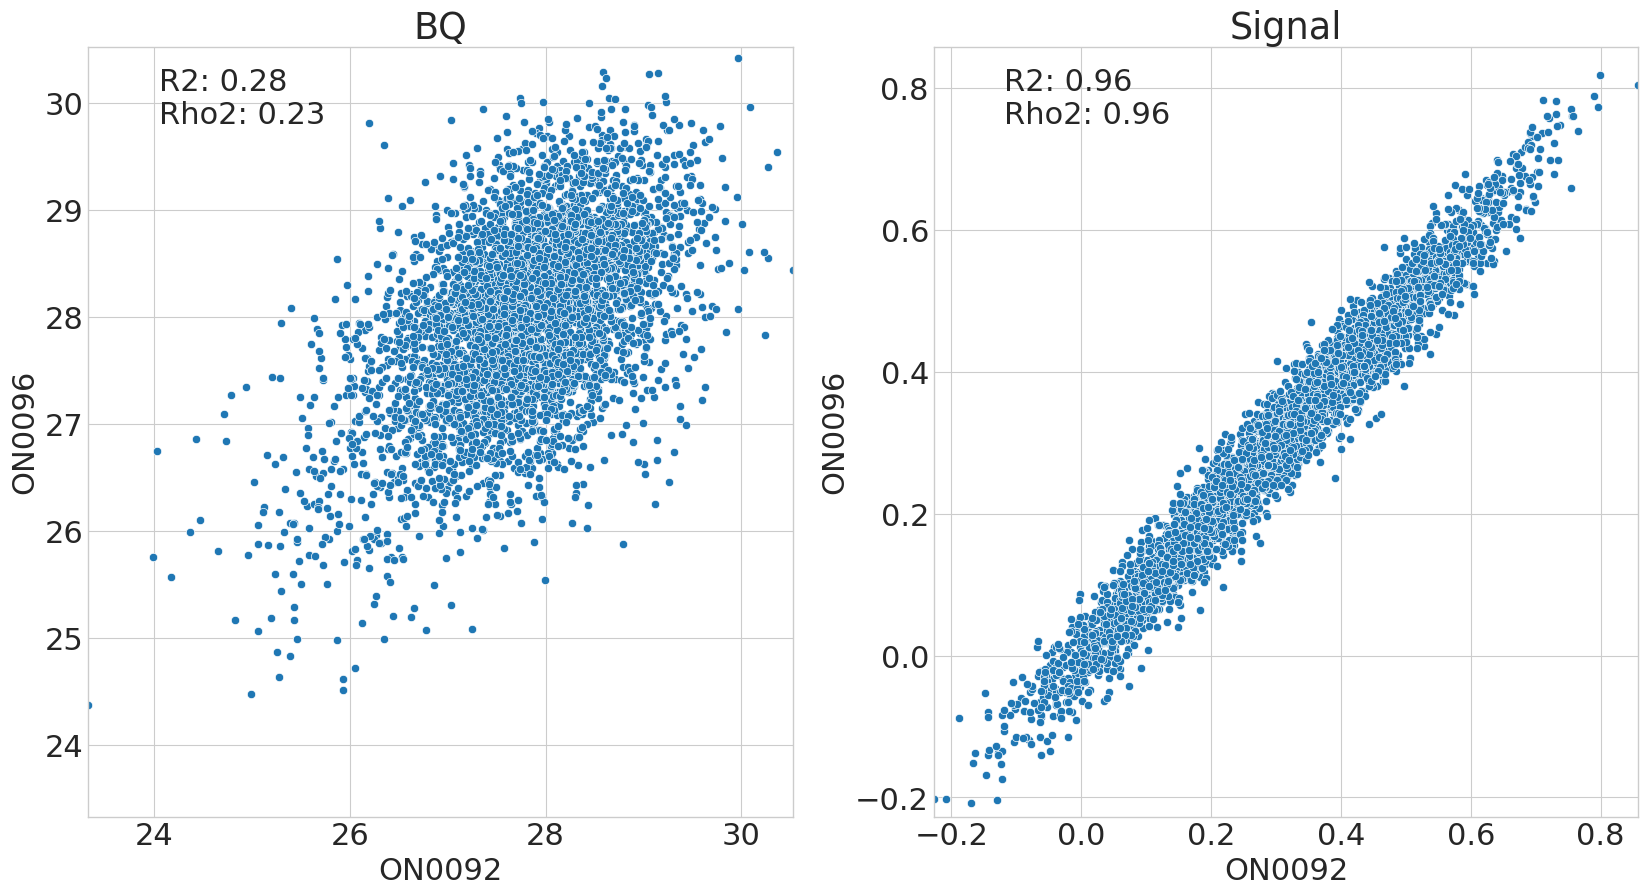

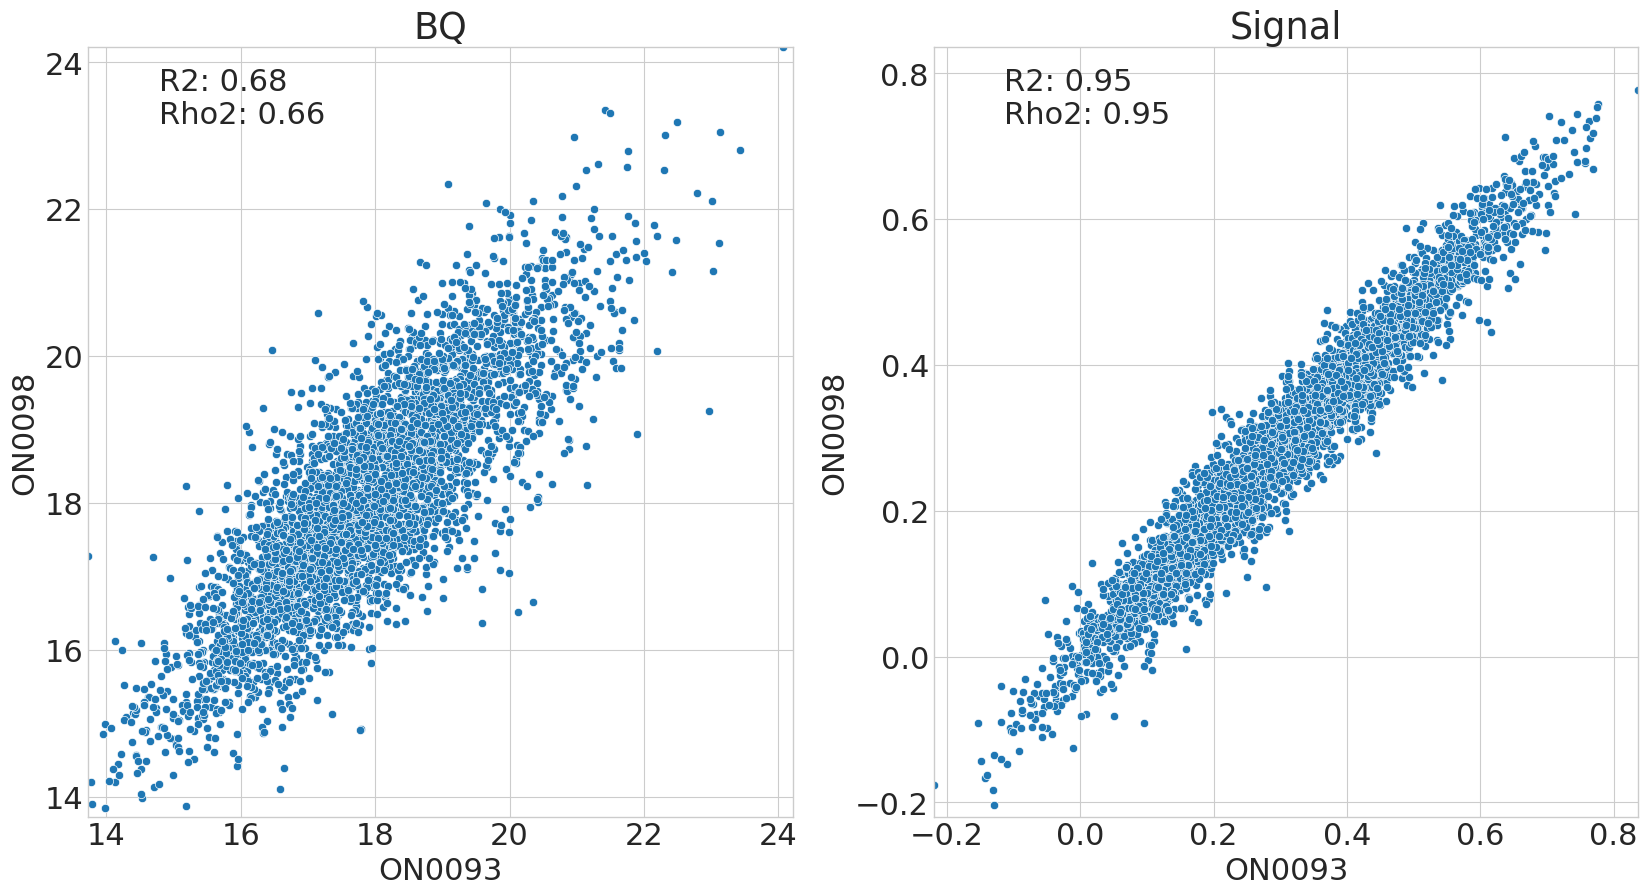

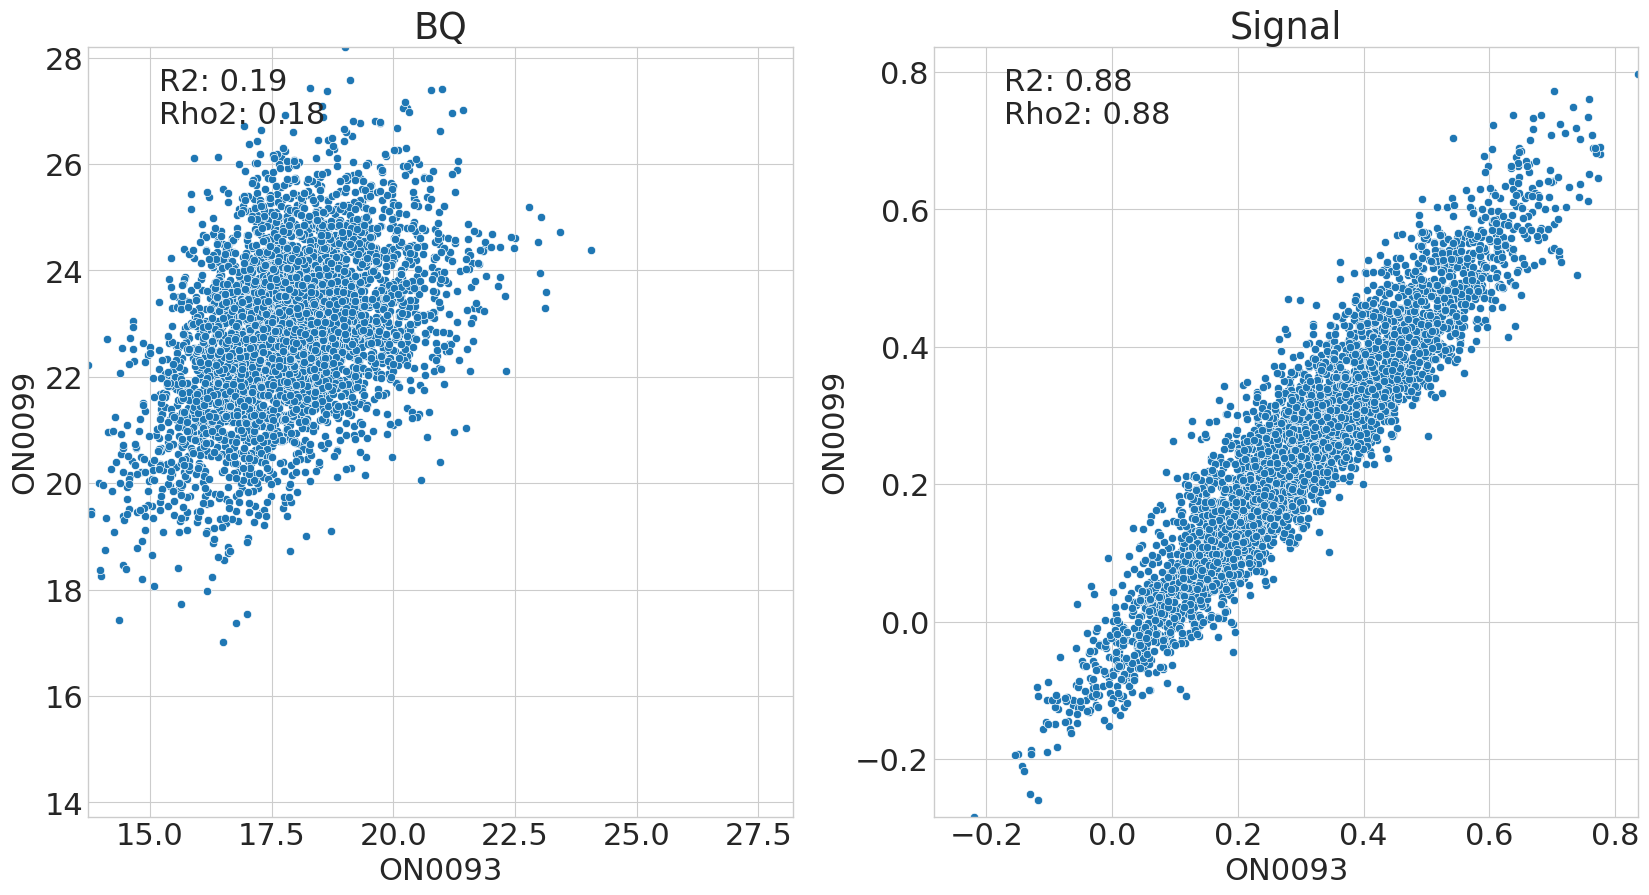

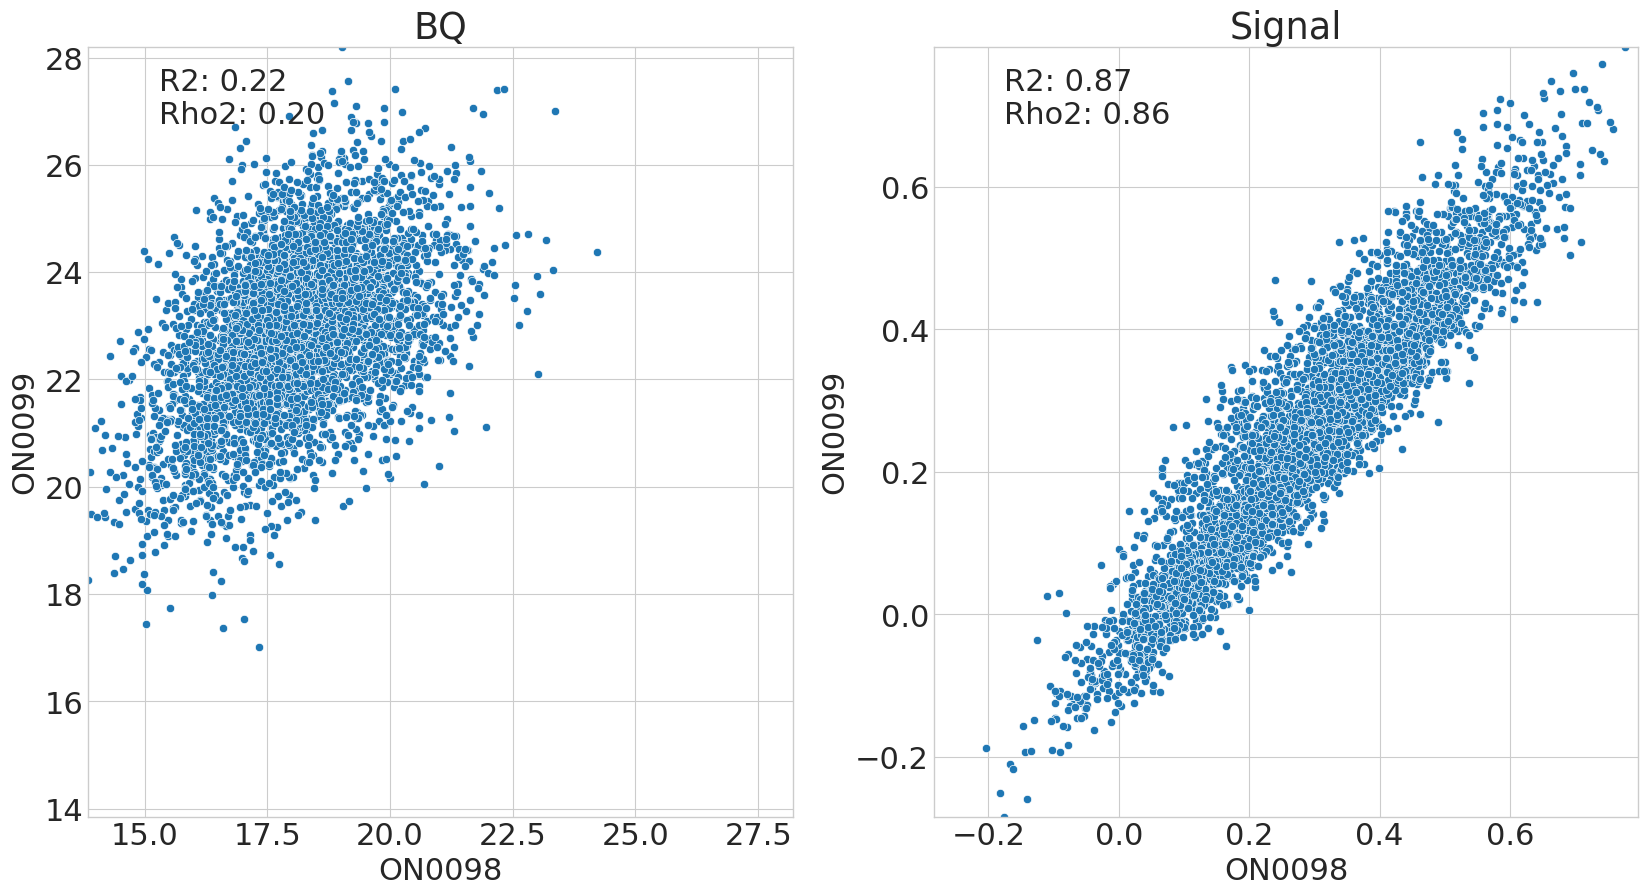

In [39]:
plot(dict_7mer, "ON0092", "ON0096")
plot(dict_7mer, "ON0093", "ON0098")
plot(dict_7mer, "ON0093", "ON0099")
plot(dict_7mer, "ON0098", "ON0099")

In [40]:
df_dict["ON0093_ON0098"] = pd.concat([df_dict["ON0093"], df_dict["ON0098"]]).copy().reset_index(drop=True)

In [42]:
dict_5mer = get_motif_signal(df_dict, key = "5mer")
dict_7mer = get_motif_signal(df_dict, key = "7mer")


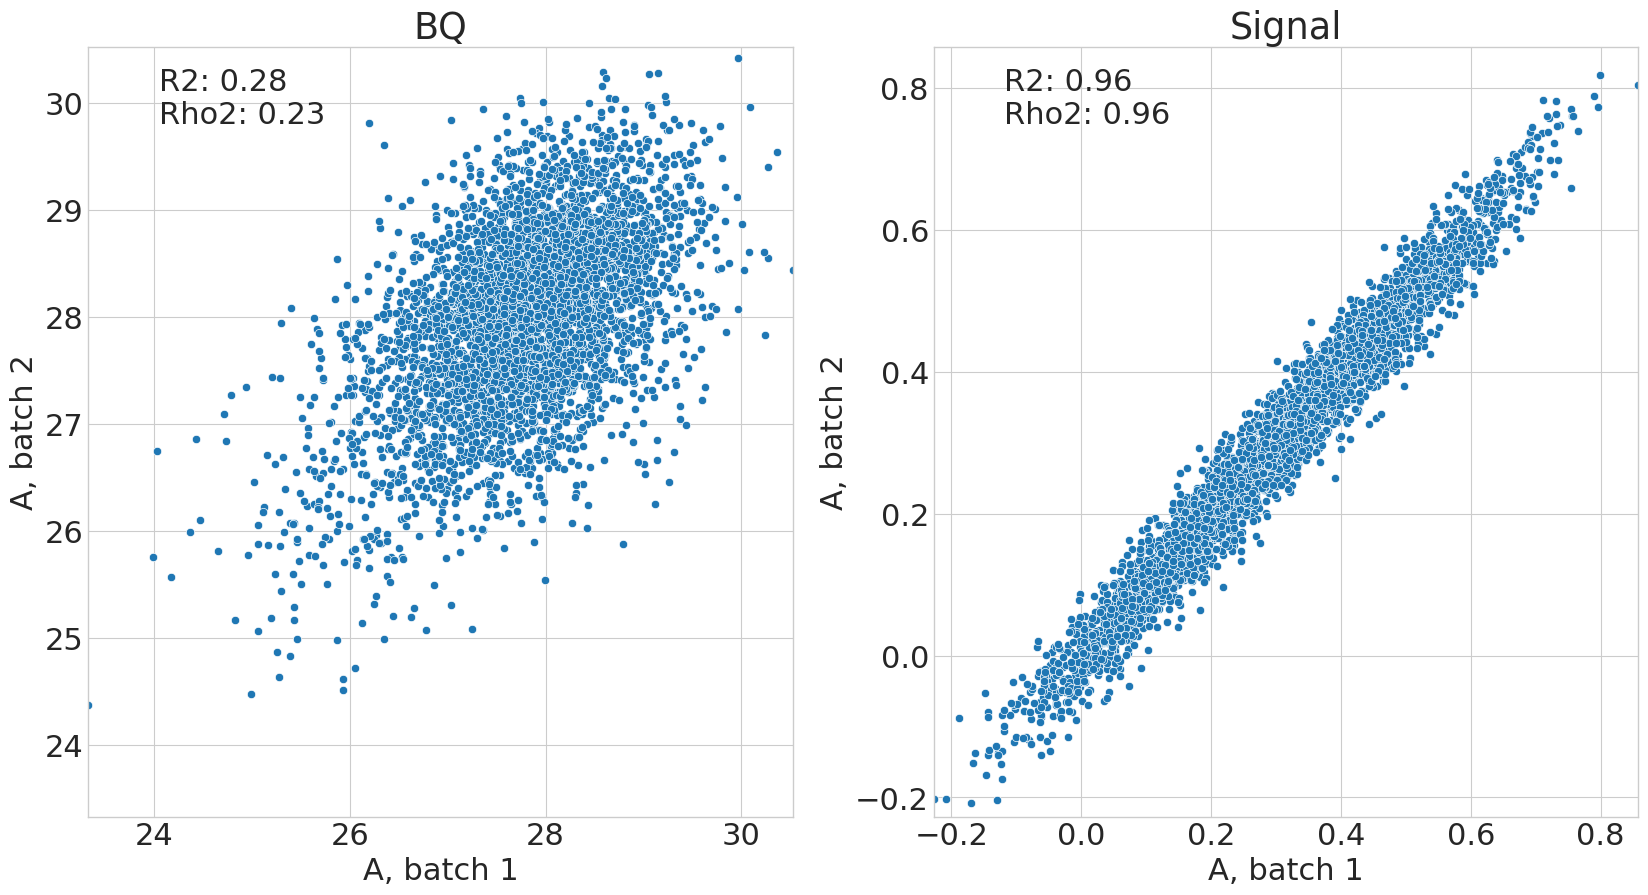

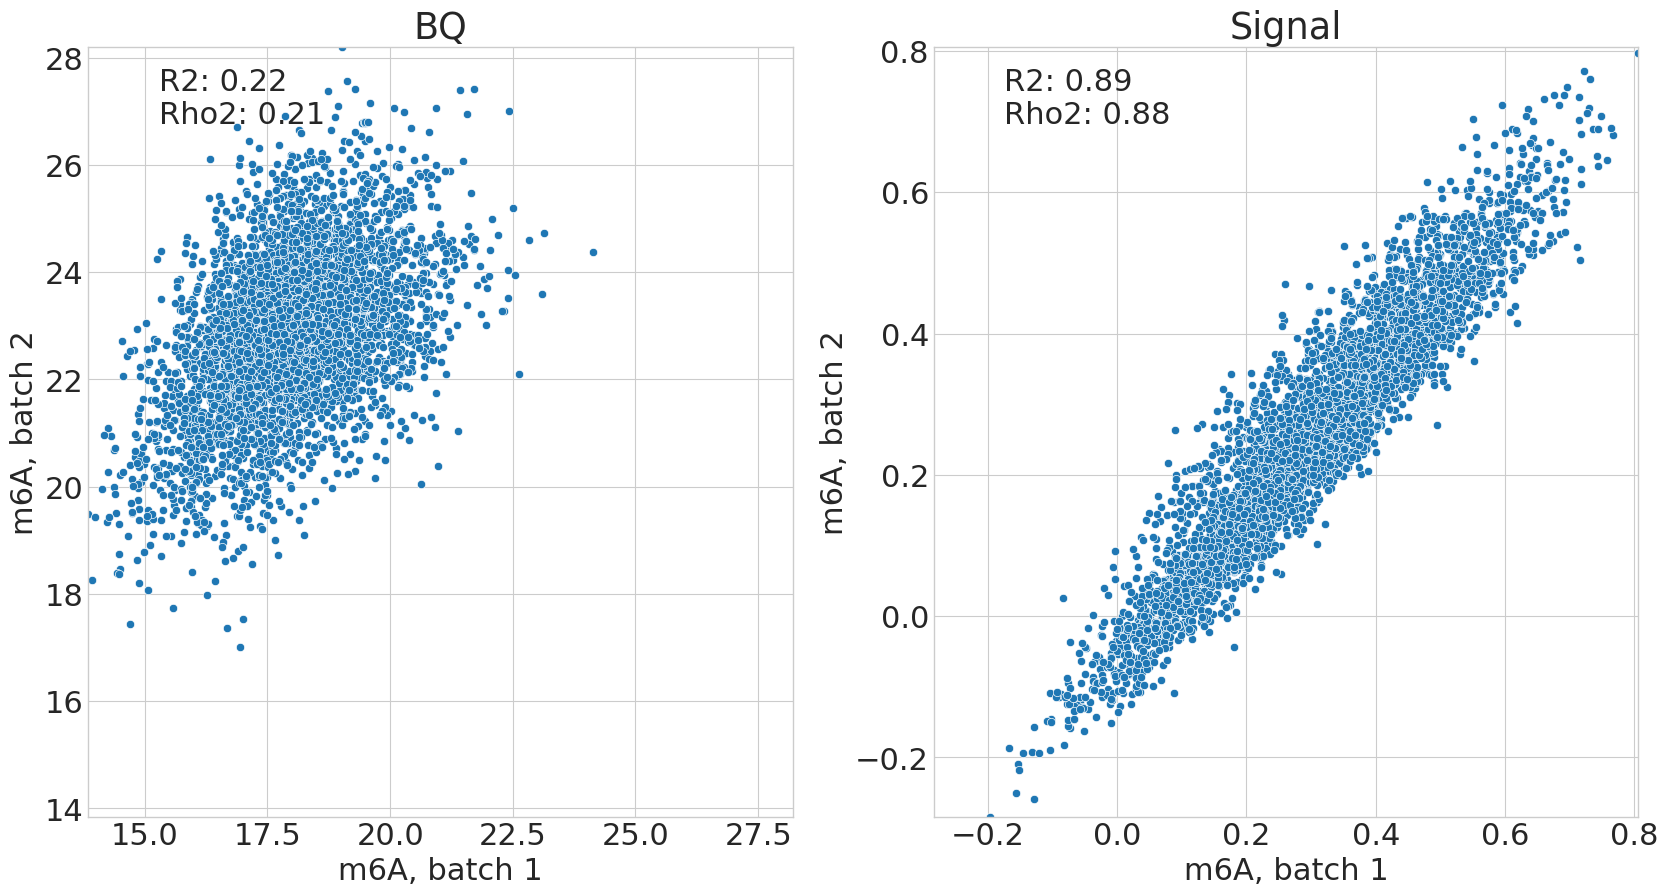

In [48]:
plot(dict_7mer, "ON0092", "ON0096", x_label="A, batch 1", y_label="A, batch 2")
plot(dict_7mer, "ON0093_ON0098", "ON0099", x_label="m6A, batch 1", y_label="m6A, batch 2")

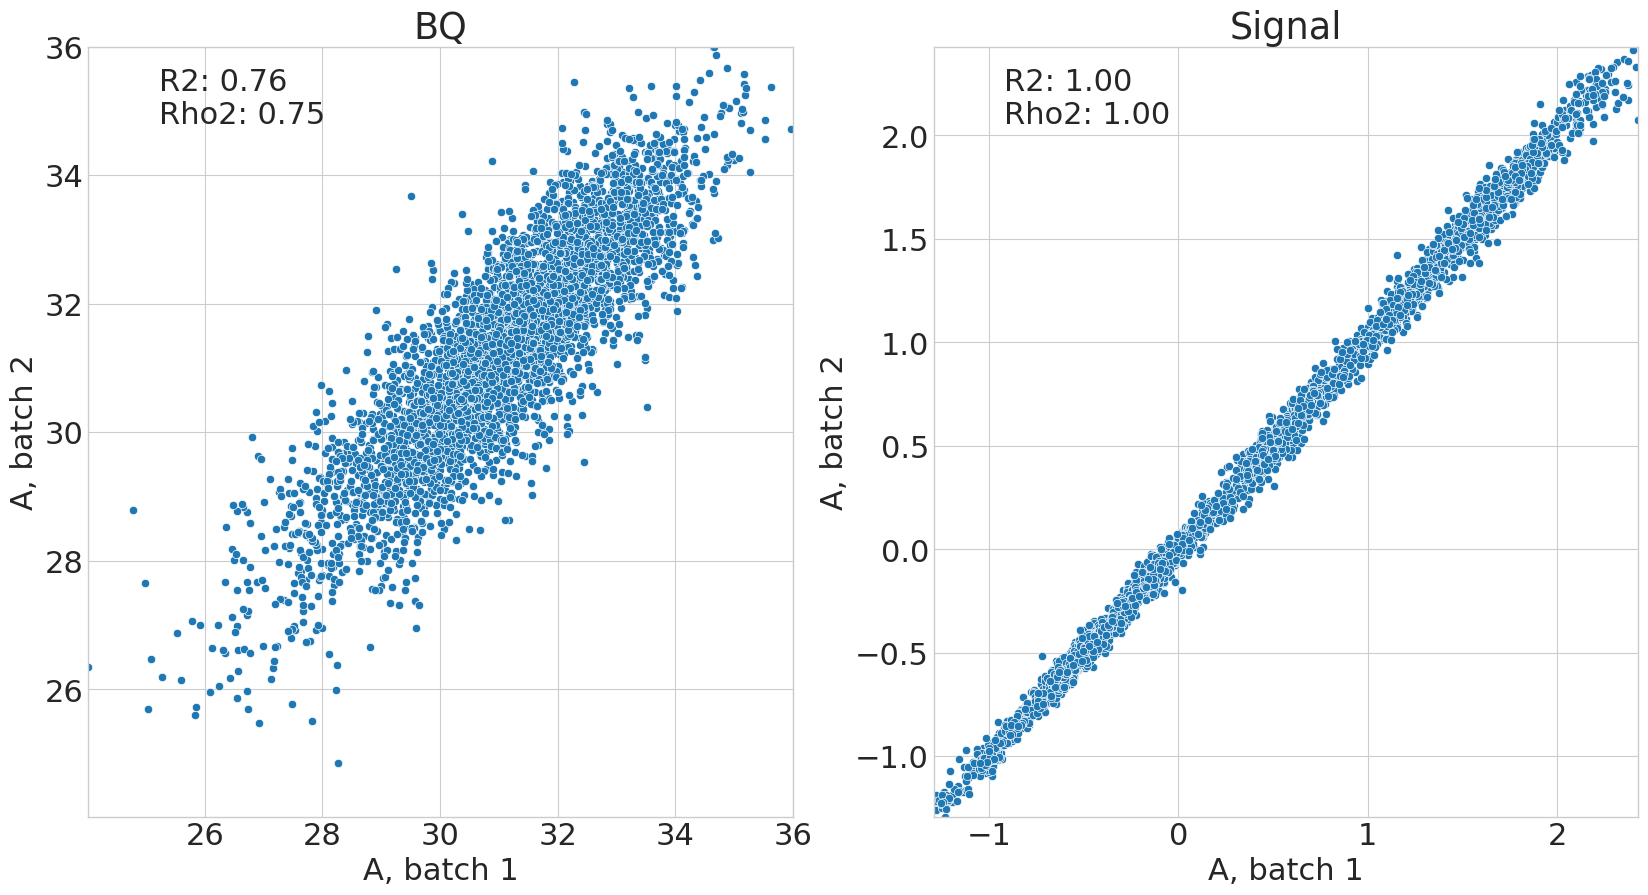

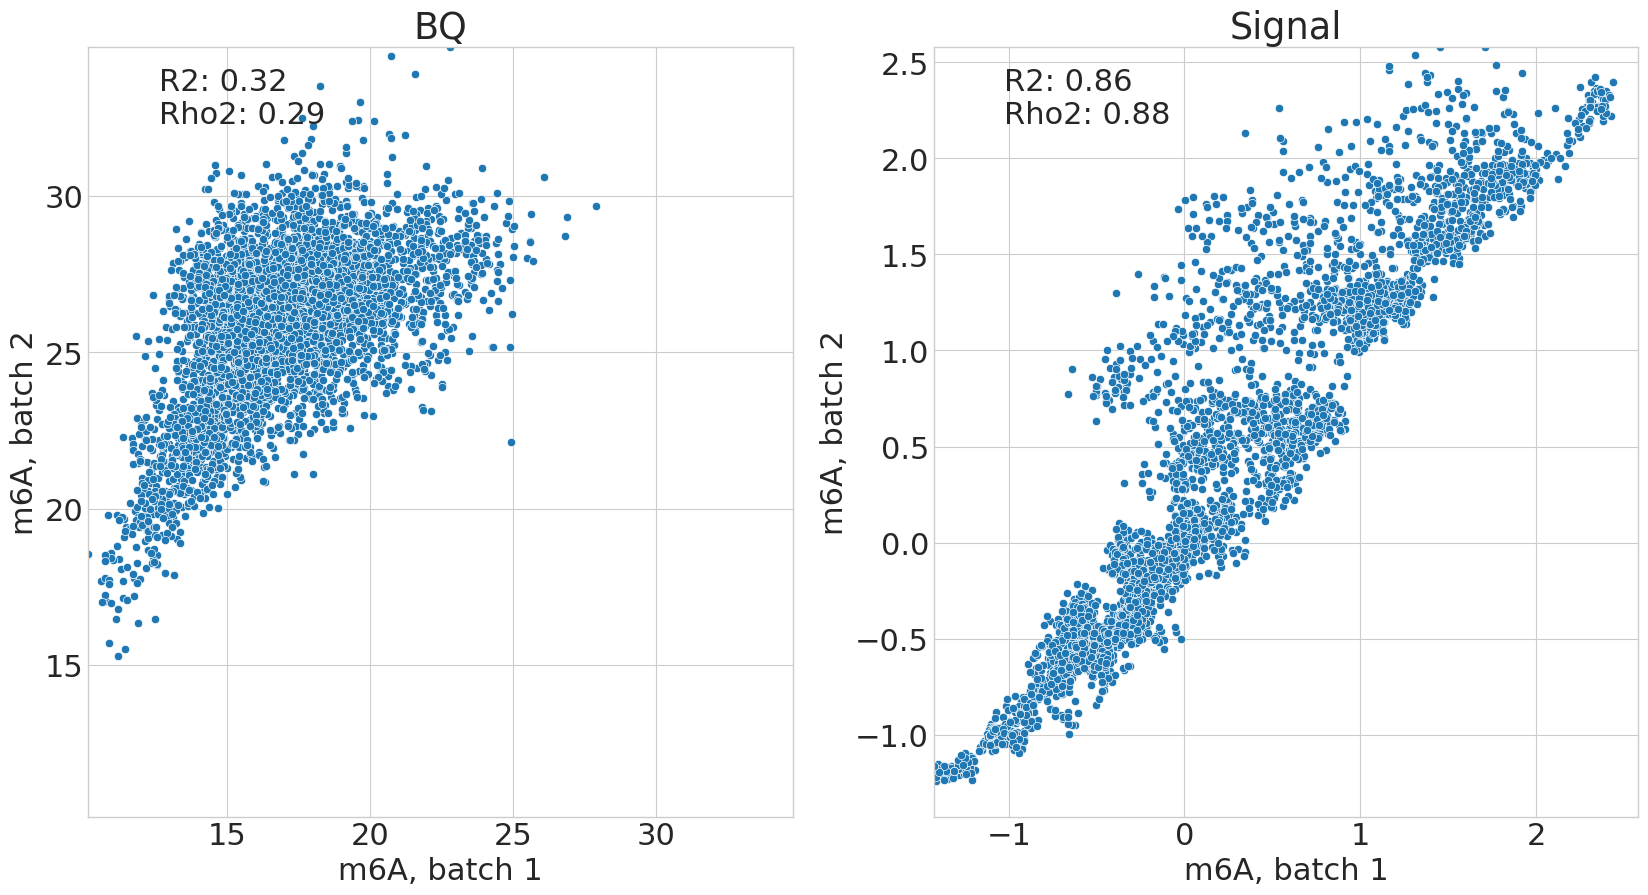

In [49]:

plot(dict_7mer, "ON0092", "ON0096", bq_feature = "bq_centre", signal_feature = "signal_centre", x_label="A, batch 1", y_label="A, batch 2")
plot(dict_7mer, "ON0093_ON0098", "ON0099", bq_feature = "bq_centre", signal_feature = "signal_centre", x_label="m6A, batch 1", y_label="m6A, batch 2")

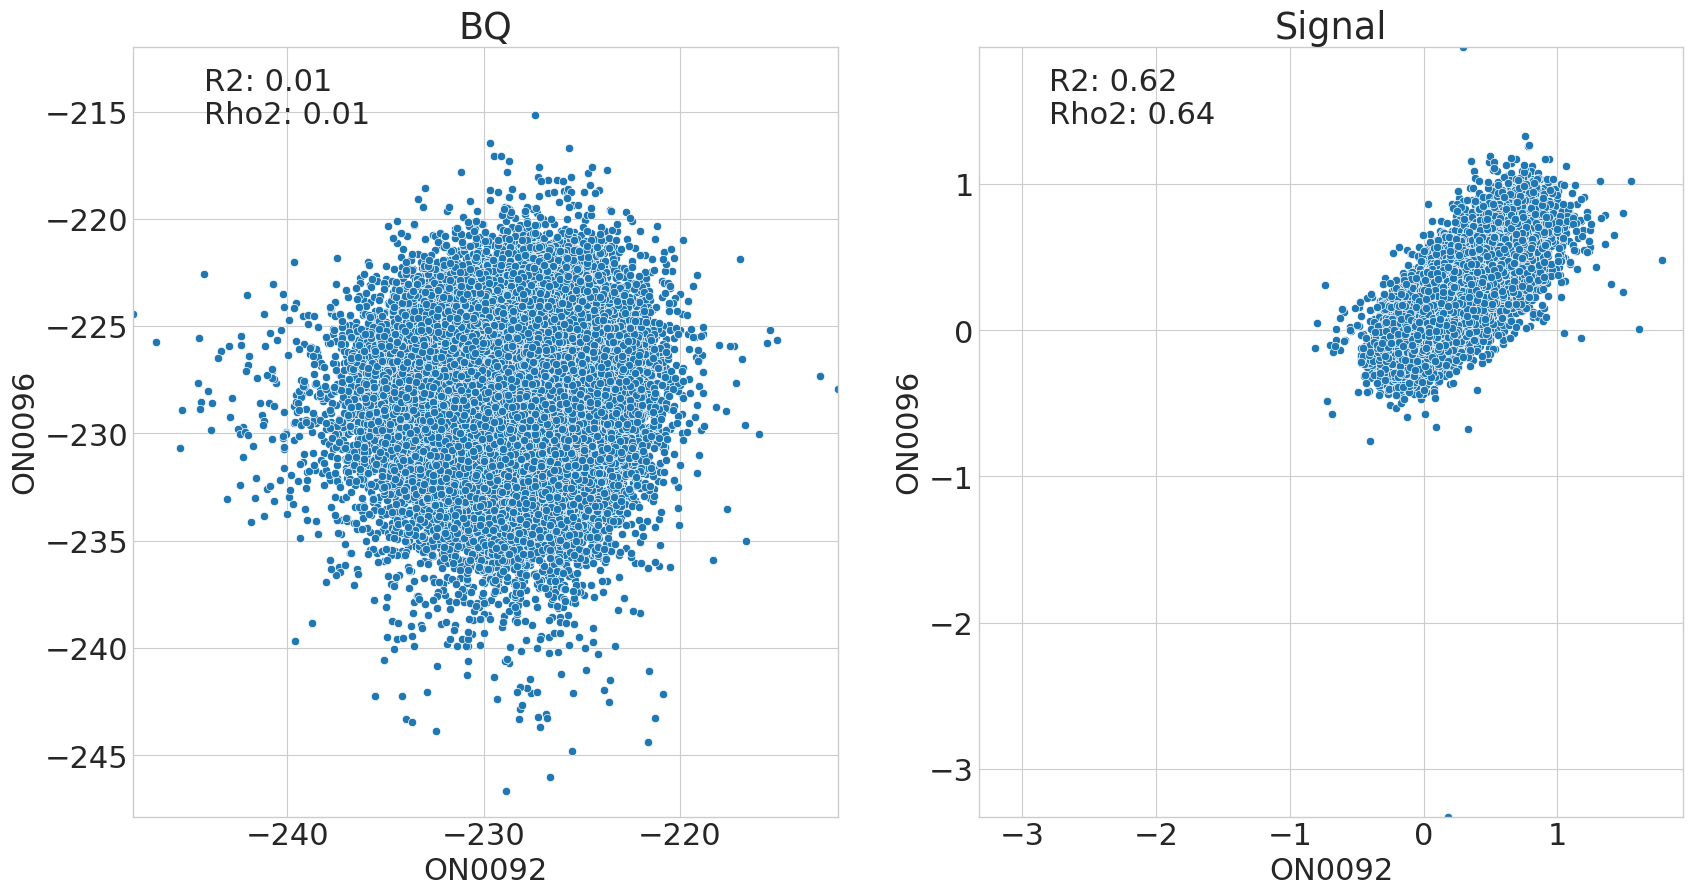

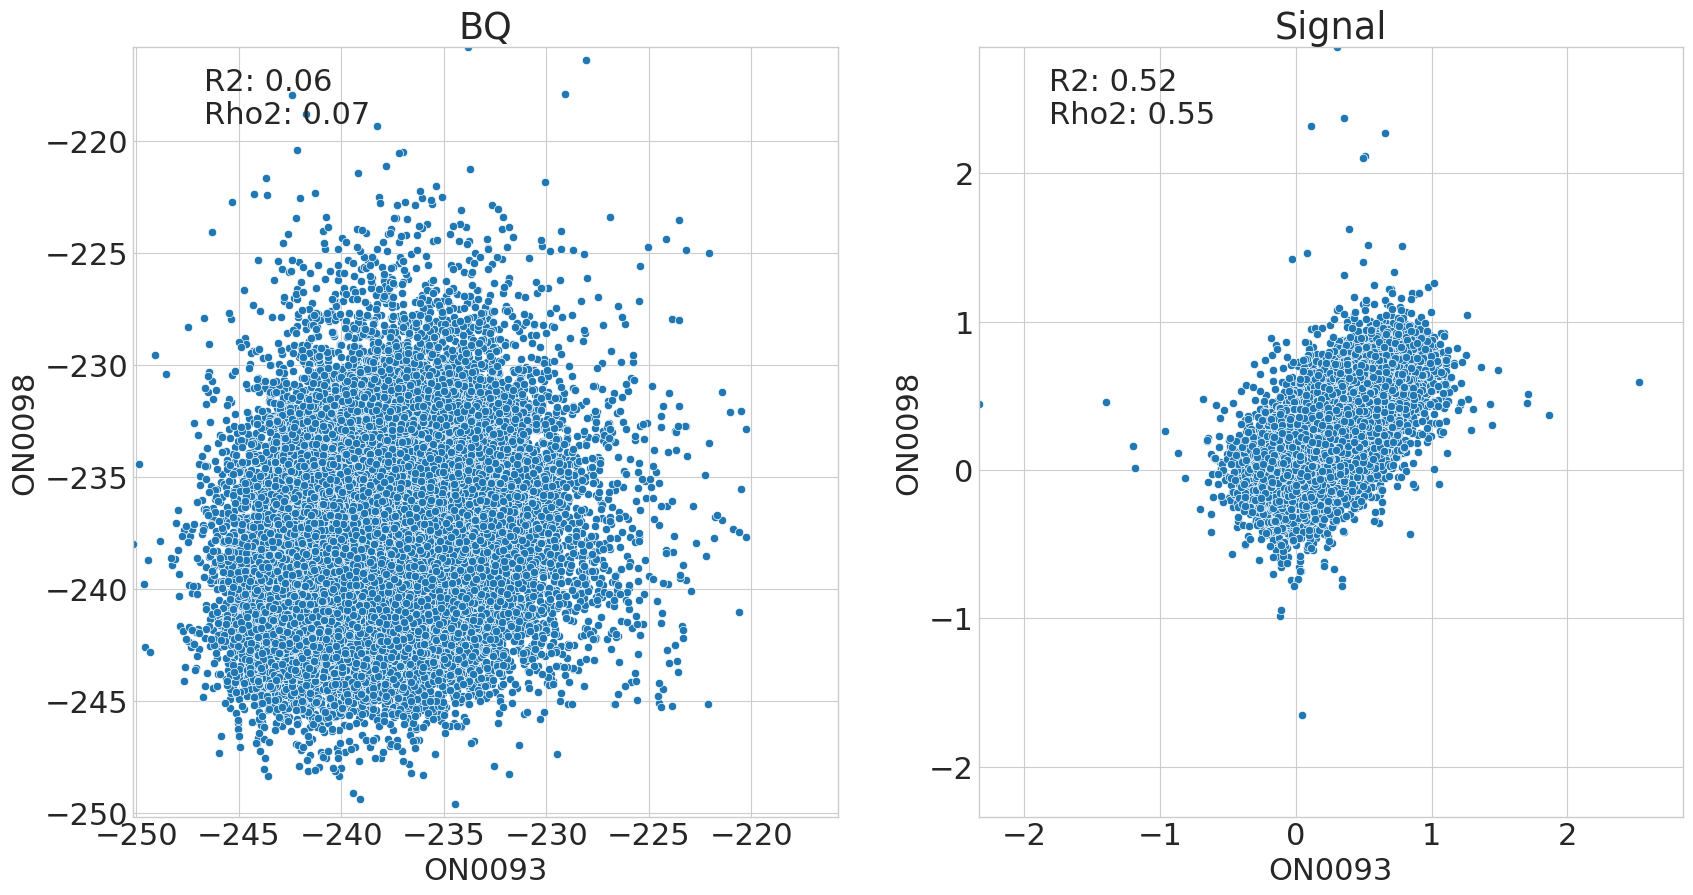

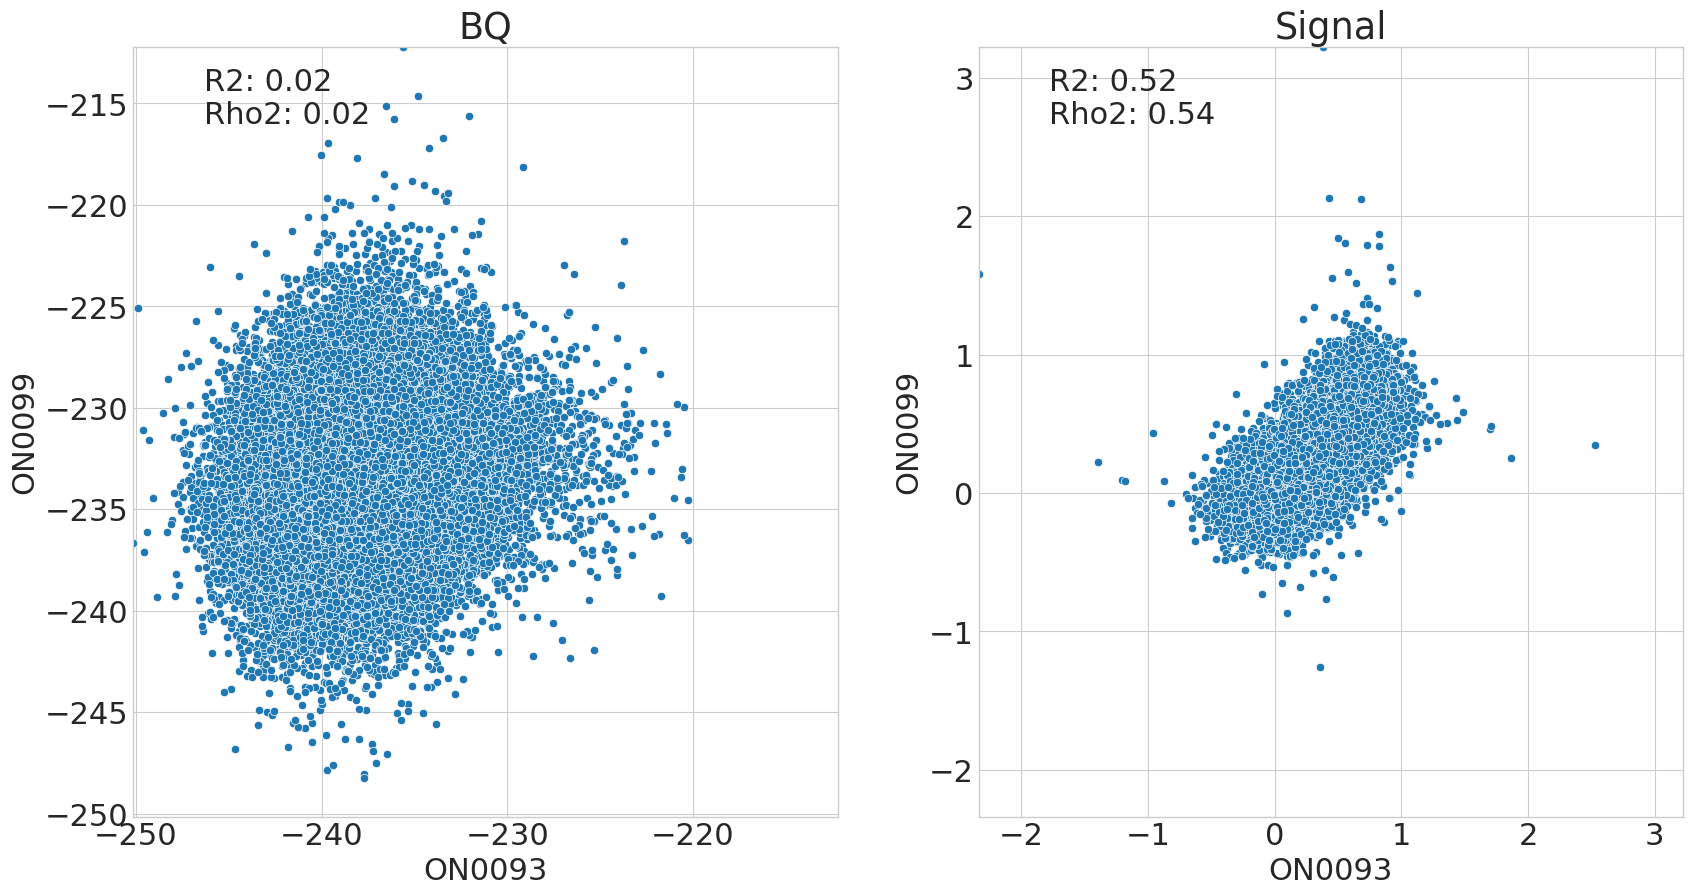

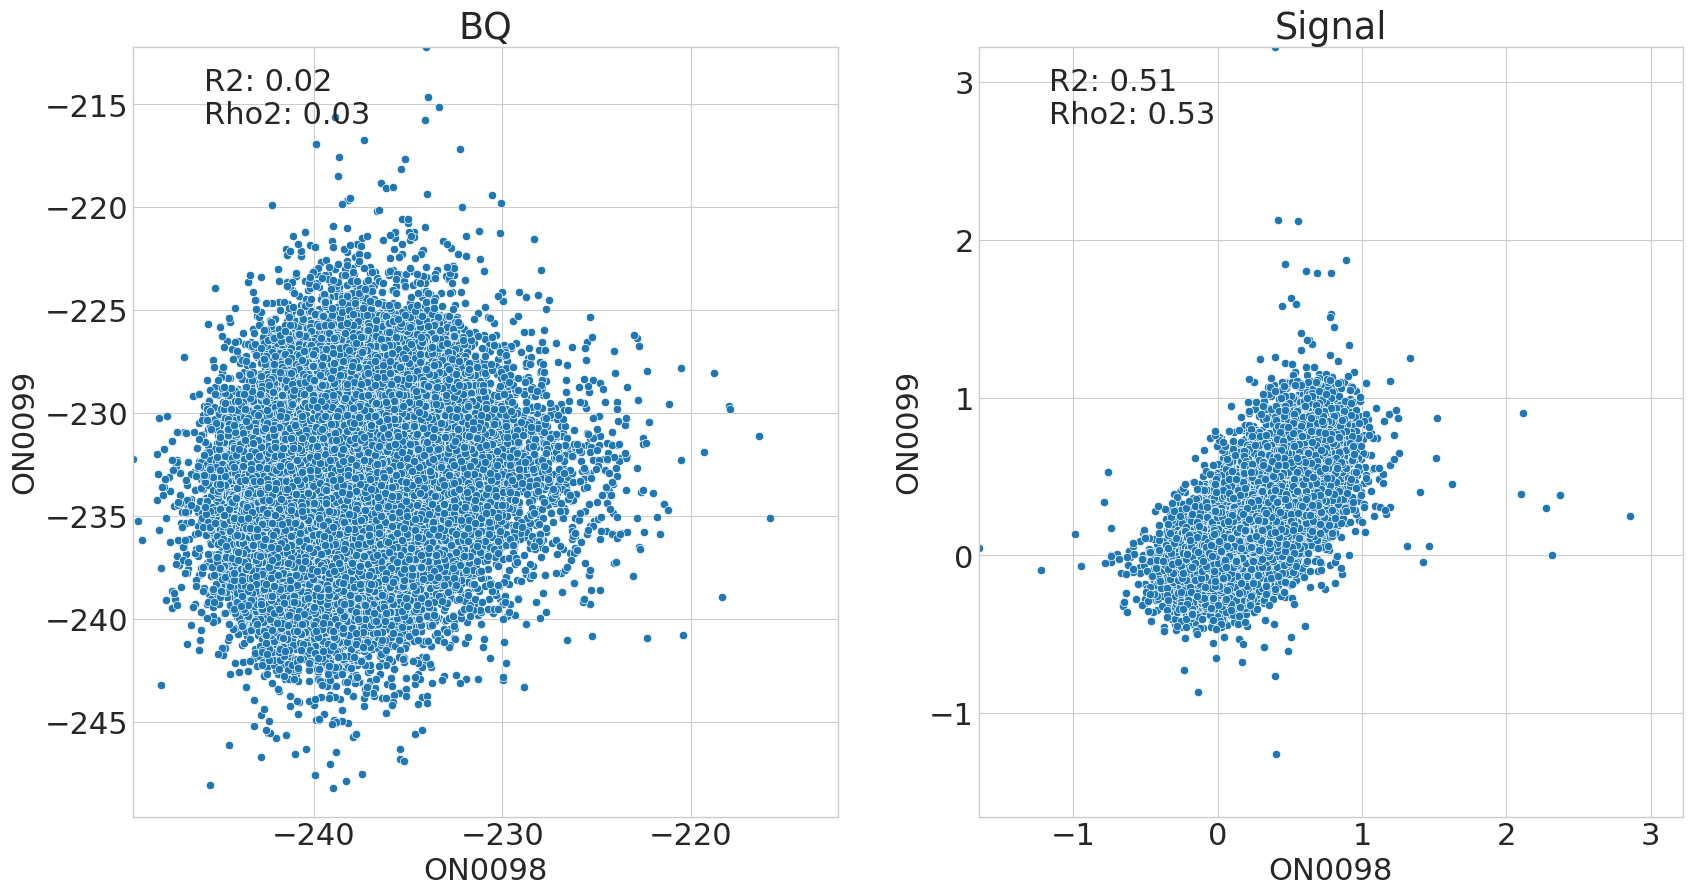

In [15]:
plot(dict_9mer, "ON0092", "ON0096")
plot(dict_9mer, "ON0093", "ON0098")
plot(dict_9mer, "ON0093", "ON0099")
plot(dict_9mer, "ON0098", "ON0099")

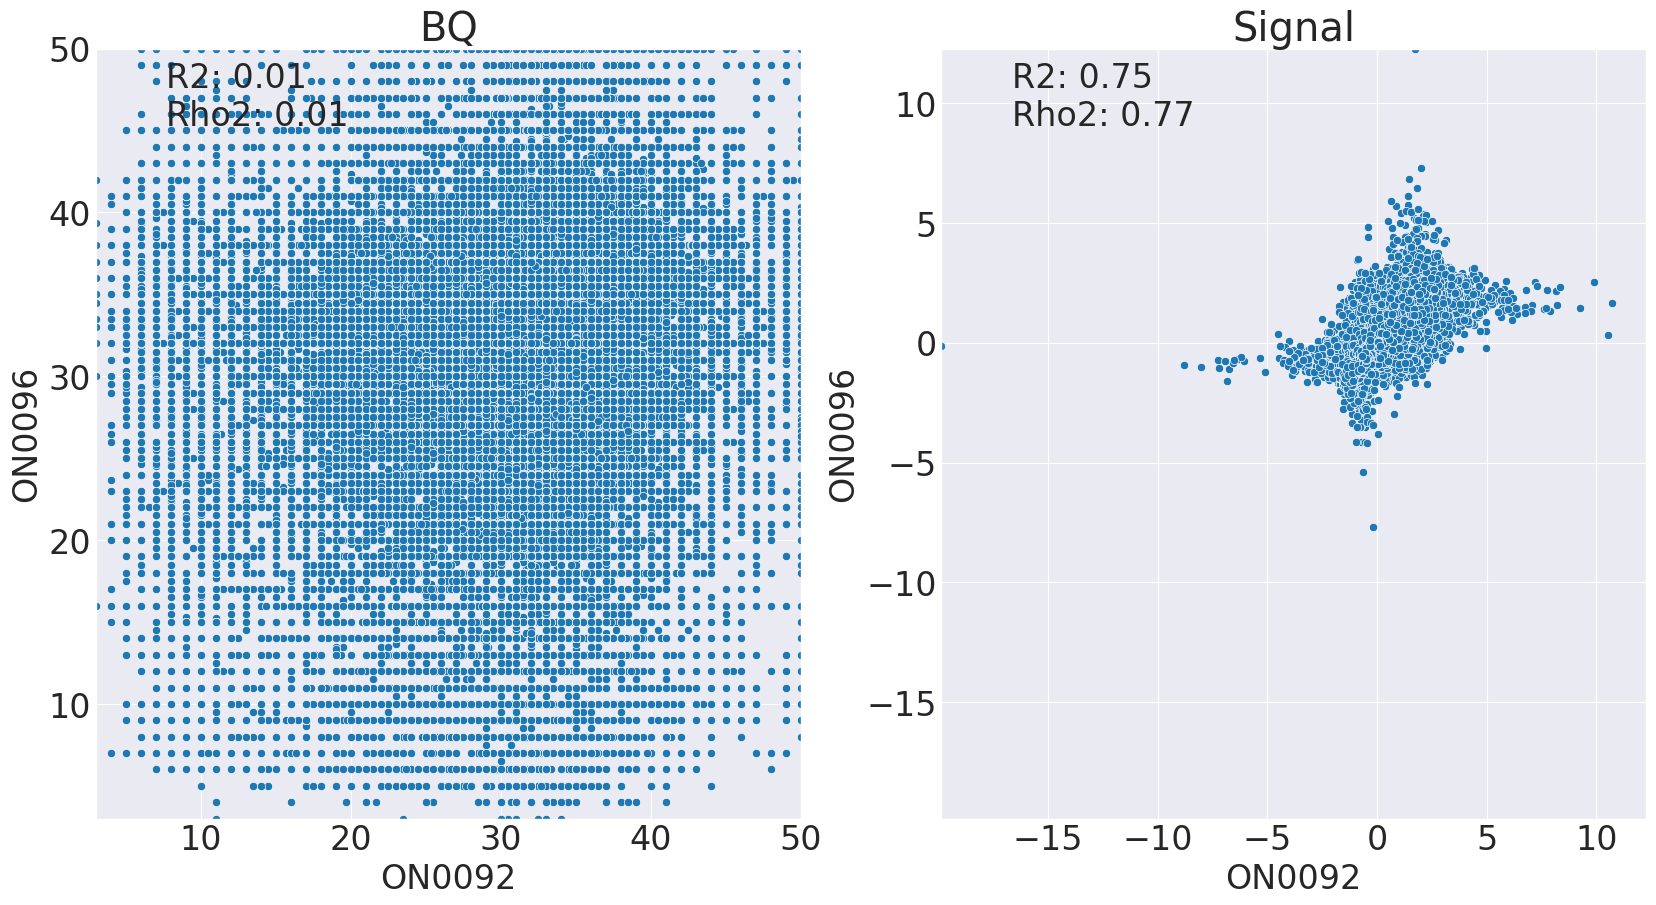

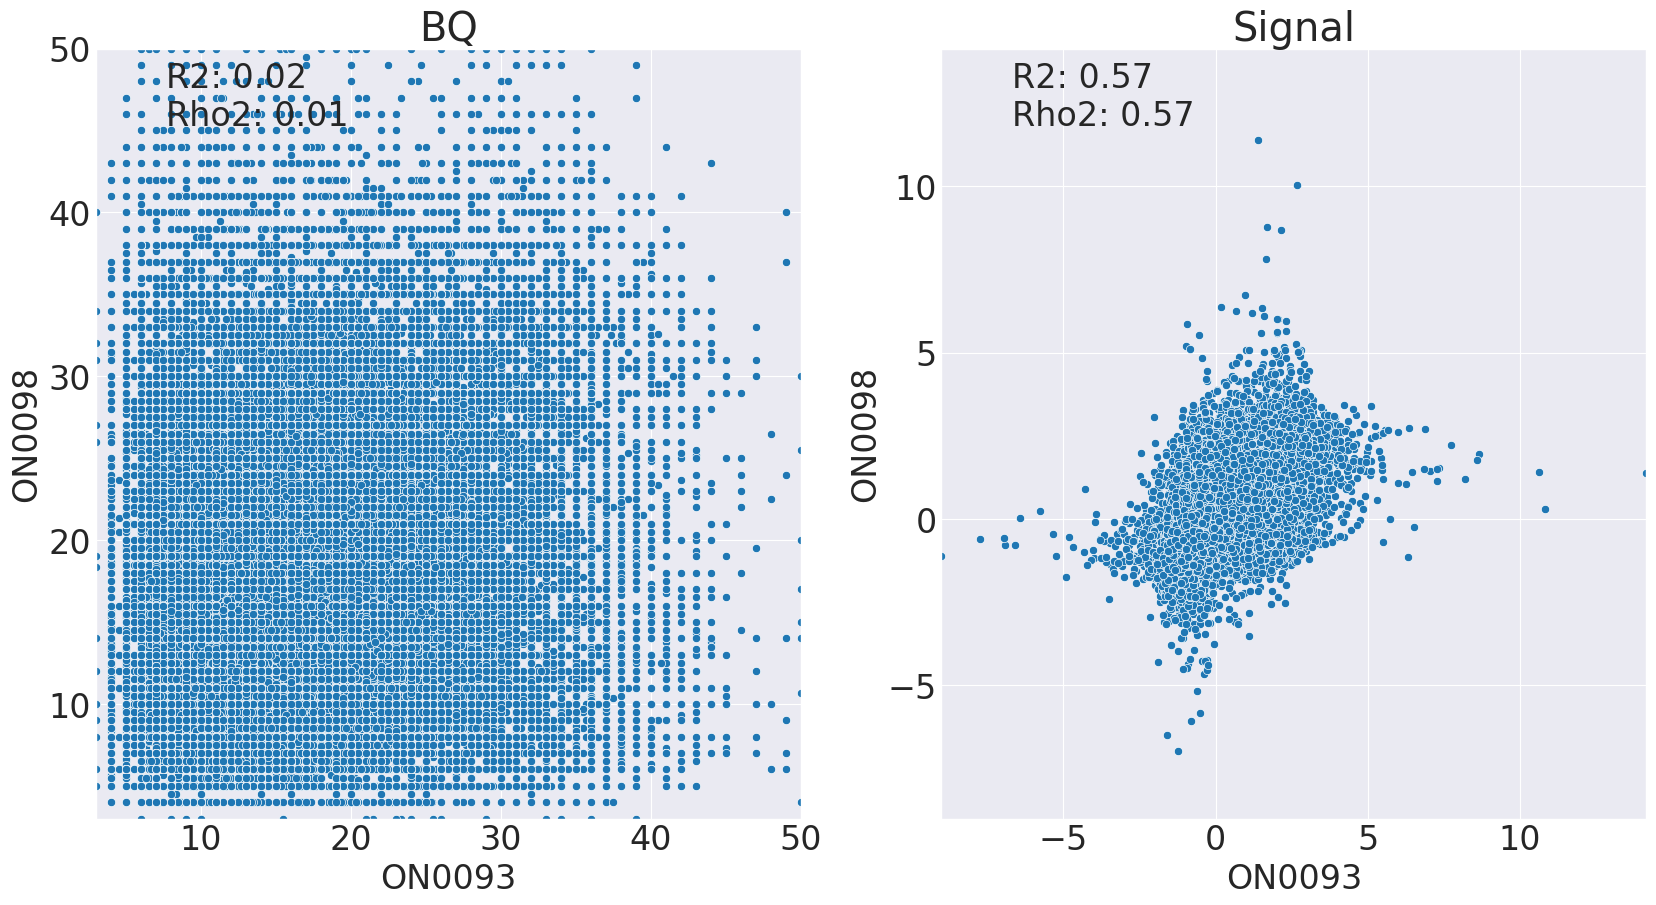

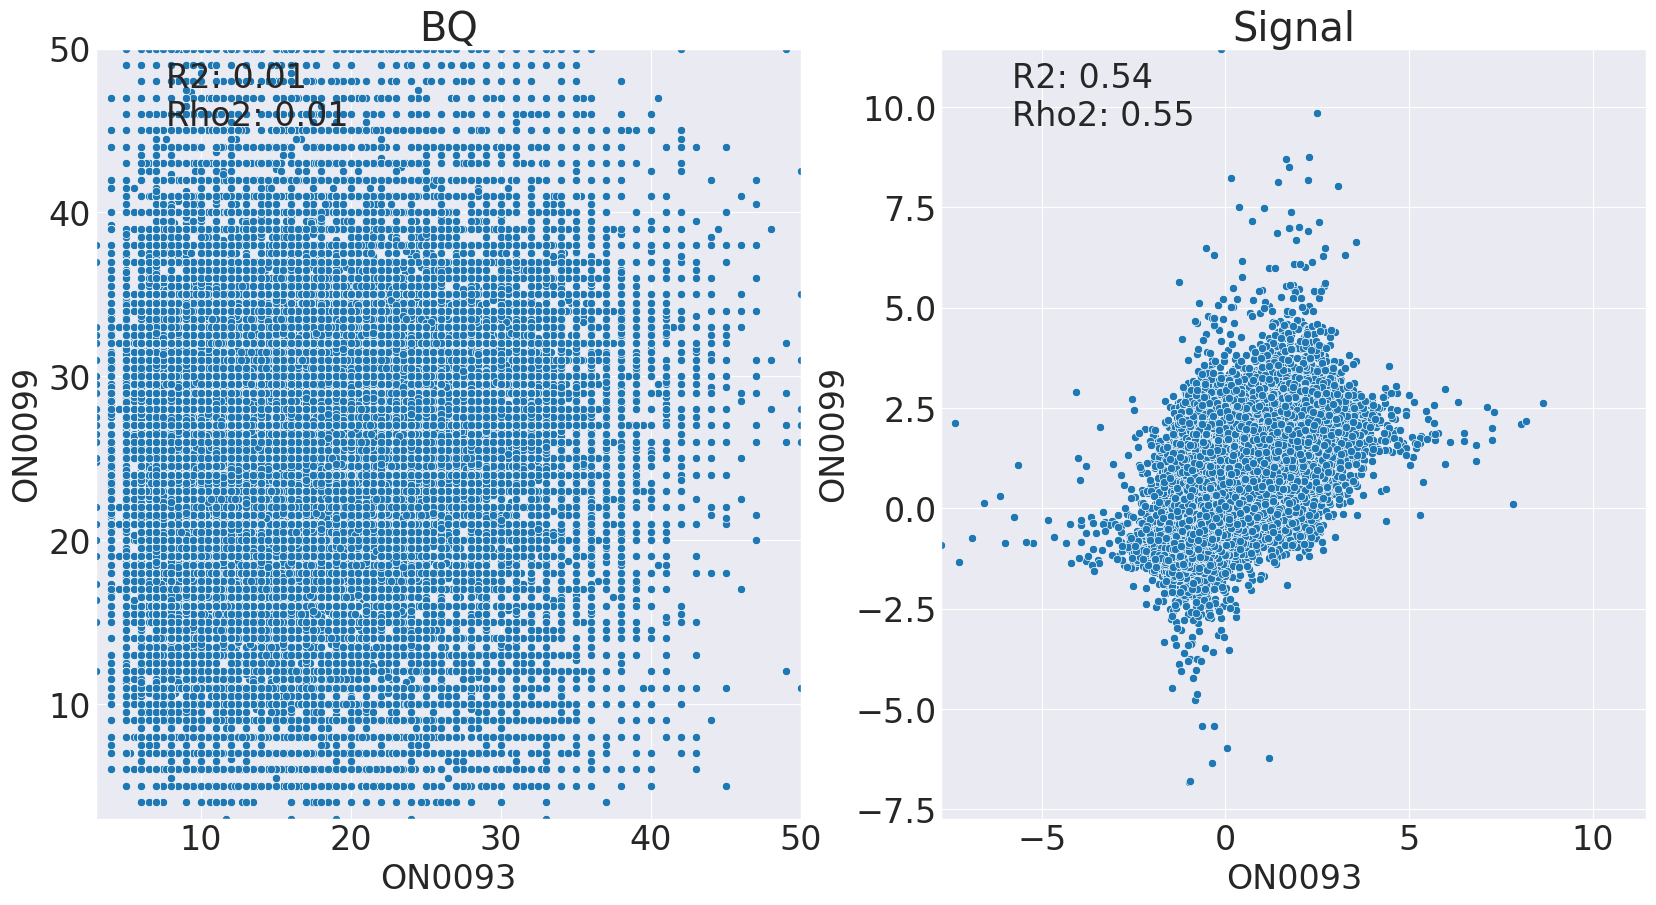

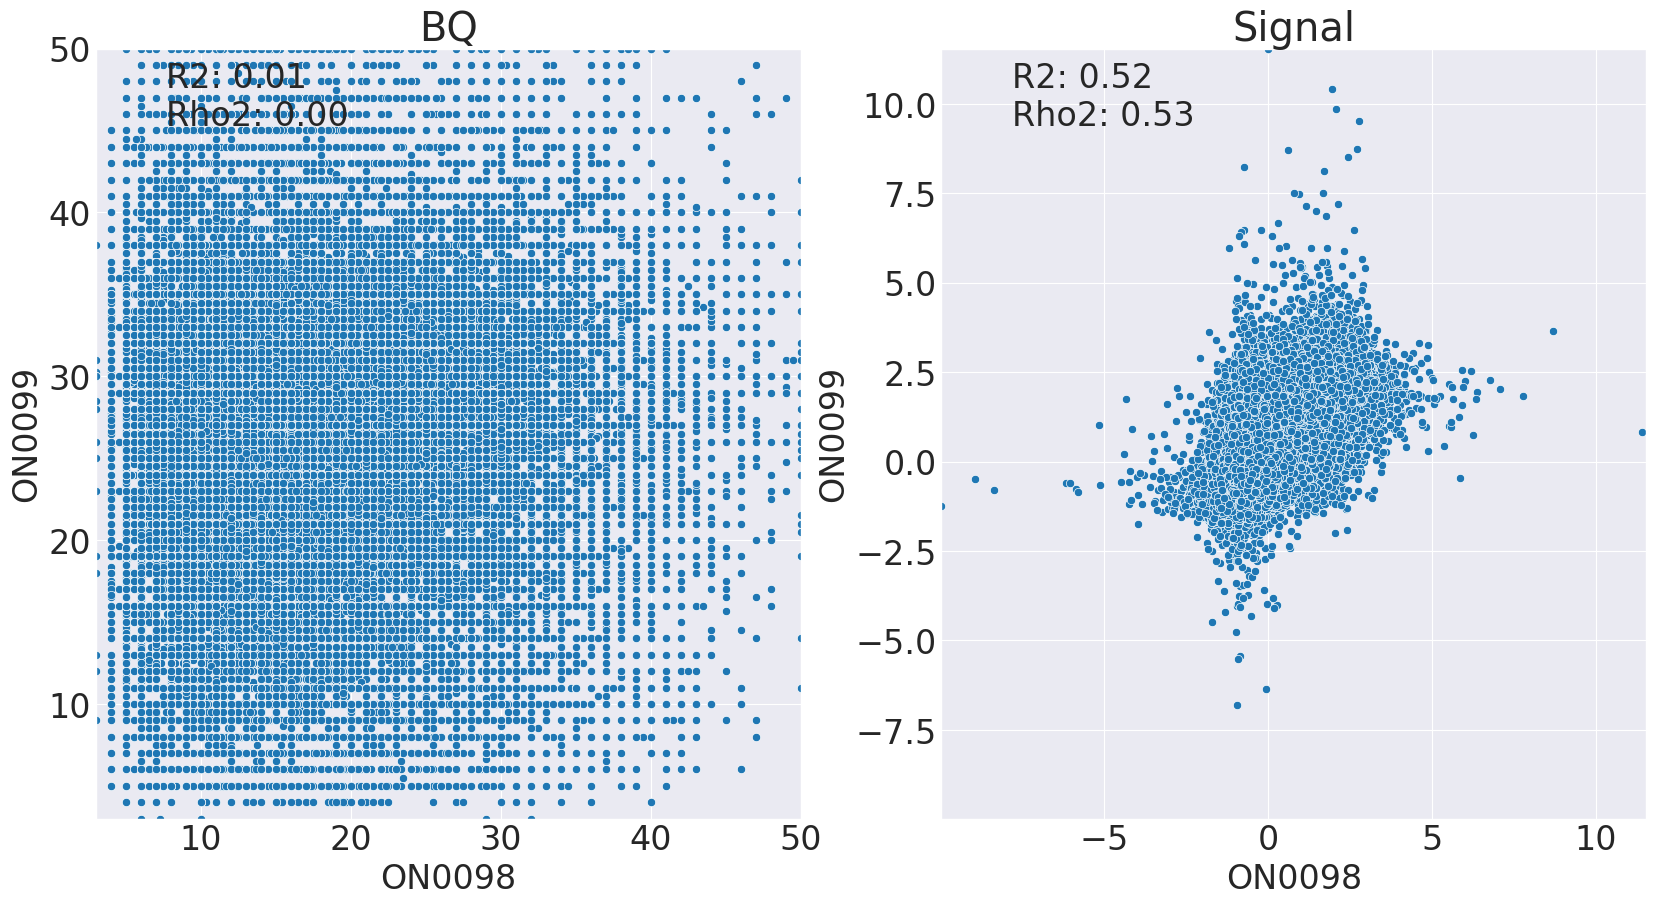

In [101]:
plot(dict_11mer, "ON0092", "ON0096")
plot(dict_11mer, "ON0093", "ON0098")
plot(dict_11mer, "ON0093", "ON0099")
plot(dict_11mer, "ON0098", "ON0099")

In [38]:

def lineplot(mean_dict, ci95_dict, length_dict, title, out_path):

    plt.rcParams.update({'font.size': 24})
    fig, ax = plt.subplots(figsize=(20,10))

    colour_list = ['royalblue', 'tomato', 'skyblue', 'lightsalmon', 'orange']

    for i, key in enumerate(mean_dict.keys()):
        colour = colour_list[i]
        mean = mean_dict[key]
        ci95 = ci95_dict[key]
        length = length_dict[key]
        width = len(mean)
        ax.plot(mean, color=colour, label=f"{key} (n={length:,})")
        ax.fill_between(np.arange(width), mean-ci95, mean+ci95,
                        color=colour, alpha=0.3)

    ax.set_title(title)
    ax.set_xlabel("Position")
    ax.set_ylabel(title)

    ax.set_xticks(np.arange(0, width, 3))
    ax.set_xticklabels(np.arange(0, width, 3))


    ## Vline at center
    ax.axvline(x=width//2, color="black", linestyle="--")

    ax.legend()
    plt.savefig(f"{out_path}/{title}_runs.pdf")
    plt.savefig(f"{out_path}/{title}_runs.png", dpi=300)
    plt.close()

    return None


In [44]:
a_df = pd.concat([df_dict["ON0092"], df_dict["ON0096"]]).copy().reset_index(drop=True)

m6a_df = []
for key in ["ON0093", "ON0098", "ON0099"]:
    df = df_dict[key]
    df = df.groupby("5mer")
    for _, sub_df in tqdm.tqdm(df, total=df.ngroups):
        m6a_df.append(sub_df.sample(1600))
m6a_df = pd.concat(m6a_df).copy().reset_index(drop=True)

df_dict_2 = {"A": a_df,
             "m6A": m6a_df}

print(a_df)
print(m6a_df)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 256/256 [00:00<00:00, 577.59it/s]


                                                        bq  \
0        [38, 38, 37, 37, 38, 38, 39, 43, 44, 39, 40, 3...   
1        [25, 27, 28, 29, 39, 44, 42, 47, 38, 39, 37, 3...   
2        [31, 30, 32, 32, 33, 34, 38, 38, 43, 39, 38, 3...   
3        [24, 34, 31, 30, 29, 29, 30, 31, 31, 30, 27, 2...   
4        [29, 34, 33, 31, 31, 32, 33, 40, 40, 38, 33, 3...   
...                                                    ...   
1228795  [39, 34, 34, 33, 31, 30, 30, 31, 32, 34, 35, 3...   
1228796  [38, 38, 38, 37, 37, 37, 36, 33, 31, 16, 15, 1...   
1228797  [35, 35, 36, 37, 39, 42, 43, 41, 39, 36, 33, 3...   
1228798  [39, 38, 38, 39, 39, 39, 38, 38, 38, 38, 39, 3...   
1228799  [32, 32, 31, 31, 31, 31, 33, 35, 33, 32, 28, 2...   

                         motif  cb_idx  \
0        UCAGGCUGAAAAAAUUUAAUC       0   
1        UUUGAGAAAAAAACAUUAGGC       0   
2        CGACCGUCAAAAAUGCAAUGC       0   
3        GAGCGCAUAAAAAGGGGCGAC       0   
4        AAGCCAAGAAAAAGCGCUGUC       0   
...

In [45]:
out_path = "/extdata4/baeklab/Hyeonseo/m6A/poster"

for feature in ["bq"]:
    feature_renamed = f"{feature}_bulk_large"
    df_dict_motif = {df_name: df for df_name, df in df_dict_2.items()}
    data_dict = {df_name: np.stack(df[feature].values) for df_name, df in df_dict_motif.items()}
    mean_dict = {df_name: np.mean(data, axis=0) for df_name, data in data_dict.items()}
    ci95_dict = {df_name: 1.96*np.std(data, axis=0)/np.sqrt(data.shape[0]) for df_name, data in data_dict.items()}
    length_dict = {df_name: data.shape[0] for df_name, data in data_dict.items()}
    lineplot(mean_dict, ci95_dict, length_dict, feature_renamed, out_path)



In [43]:

a_df = []
for key in ["ON0092", "ON0096"]:
    df = df_dict[key]
    df = df.groupby("5mer")
    for _, sub_df in tqdm.tqdm(df, total=df.ngroups):
        a_df.append(sub_df.sample(150))
a_df = pd.concat(a_df).copy().reset_index(drop=True)

m6a_df = []
for key in ["ON0093", "ON0098", "ON0099"]:
    df = df_dict[key]
    df = df.groupby("5mer")
    for _, sub_df in tqdm.tqdm(df, total=df.ngroups):
        m6a_df.append(sub_df.sample(100))
m6a_df = pd.concat(m6a_df).copy().reset_index(drop=True)

df_dict_2 = {"A": a_df,
             "m6A": m6a_df}

print(a_df)
print(m6a_df)

out_path = "/extdata4/baeklab/Hyeonseo/m6A/poster"

for feature in ["bq"]:
    feature_renamed = f"{feature}_bulk"
    df_dict_motif = {df_name: df for df_name, df in df_dict_2.items()}
    data_dict = {df_name: np.stack(df[feature].values) for df_name, df in df_dict_motif.items()}
    mean_dict = {df_name: np.mean(data, axis=0) for df_name, data in data_dict.items()}
    ci95_dict = {df_name: 1.96*np.std(data, axis=0)/np.sqrt(data.shape[0]) for df_name, data in data_dict.items()}
    length_dict = {df_name: data.shape[0] for df_name, data in data_dict.items()}
    lineplot(mean_dict, ci95_dict, length_dict, feature_renamed, out_path)



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 256/256 [00:00<00:00, 764.99it/s]


                                                      bq  \
0      [17, 18, 23, 13, 13, 13, 13, 33, 37, 37, 34, 3...   
1      [21, 19, 24, 23, 27, 26, 27, 30, 30, 31, 30, 1...   
2      [33, 34, 35, 34, 33, 33, 35, 37, 39, 36, 34, 2...   
3      [33, 32, 33, 30, 28, 33, 30, 36, 29, 33, 25, 2...   
4      [27, 27, 29, 26, 31, 33, 37, 41, 44, 37, 45, 4...   
...                                                  ...   
76795  [29, 28, 28, 29, 29, 30, 30, 31, 32, 31, 30, 3...   
76796  [32, 32, 32, 32, 33, 33, 33, 34, 35, 33, 32, 3...   
76797  [36, 36, 35, 33, 32, 31, 28, 17, 6, 4, 4, 6, 6...   
76798  [29, 29, 30, 28, 28, 28, 28, 31, 33, 13, 13, 1...   
76799  [36, 34, 33, 34, 33, 33, 35, 34, 33, 34, 29, 3...   

                       motif  cb_idx  \
0      CACAACGUAAAAAGCUACGGC       1   
1      CAUCUGCUAAAAAGGAUAAUC       1   
2      UGAAAGUAAAAAACCAGAACA       0   
3      AGACACAAAAAAACAGCACAG       1   
4      CGUCGGGGAAAAAAGGCUUCU       0   
...                      ...     ...   

In [46]:
bq_ext_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/plot/block_070/perfect_block_df_dict_extended.pkl")

In [47]:
print(bq_ext_df)

{'ON0092 (cA)':                                      read_id  pos_RM  \
0       02823dd9-0852-4efe-83e1-94055929eee8     183   
1       2749dcba-60f3-4f2a-a151-86f7cd73fa0a     176   
2       b0097ee1-e523-4f10-b208-0790d71aa0b0      66   
3       1998f072-d092-4657-b349-b8305496469a     183   
4       a92a62ee-3785-4c34-9b6b-70c6a8f8b43a     169   
...                                      ...     ...   
999995  1634cc00-791c-4c69-a49d-edfebfc269c3     290   
999996  e097f0aa-4e6c-4bc3-8c35-da975cfc7904      96   
999997  73cb2aa5-340a-4929-a473-551d245754af      99   
999998  e0dbf4ec-d6f1-4eeb-b13c-8f1261de705a     139   
999999  260752c8-096d-4911-82ed-e3e99b5df2fe     195   

                                                       bq  
0       [26, 22, 21, 22, 22, 22, 23, 32, 31, 30, 30, 3...  
1       [24, 24, 26, 28, 29, 29, 30, 30, 27, 28, 28, 2...  
2       [35, 35, 36, 35, 35, 32, 30, 30, 30, 30, 31, 3...  
3       [17, 28, 33, 34, 34, 33, 31, 31, 31, 32, 34, 3...  
4       [13

In [63]:


def lineplot(mean_dict, ci95_dict, length_dict, title, out_path):

    plt.rcParams.update({'font.size': 24})
    fig, ax = plt.subplots(figsize=(20,10))

    colour_list = ['royalblue', 'tomato', 'skyblue', 'lightsalmon', 'orange']

    for i, key in enumerate(mean_dict.keys()):
        colour = colour_list[i]
        mean = mean_dict[key]
        ci95 = ci95_dict[key]
        length = length_dict[key]
        width = len(mean)
        ax.plot(mean, color=colour, label=f"{key} (n={length:,})", lw = 3)
        ax.fill_between(np.arange(width), mean-ci95, mean+ci95,
                        color=colour, alpha=0.3)
    
    ax.set_title(title)
    ax.set_xlabel("Position")
    ax.set_ylabel(title)

    ax.set_xticks(np.arange(0, width, 3))
    ax.set_xticklabels(np.arange(0, width, 3))


    ## Vline at center
    ax.axvline(x=width//2, color="black", linestyle="--")

    ax.legend()
    plt.show()
    plt.close()

    return None


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 256/256 [00:00<00:00, 714.02it/s]


                                                     bq  \
0     [12, 12, 27, 32, 34, 37, 38, 34, 34, 27, 26, 2...   
1     [29, 23, 17, 18, 18, 30, 30, 31, 36, 34, 34, 3...   
2     [23, 12, 8, 8, 8, 8, 9, 14, 16, 16, 15, 16, 16...   
3     [45, 44, 46, 45, 45, 46, 44, 44, 47, 45, 45, 4...   
4     [36, 39, 37, 37, 37, 36, 36, 38, 37, 36, 37, 3...   
...                                                 ...   
7675  [10, 11, 15, 23, 33, 31, 31, 28, 28, 26, 28, 3...   
7676  [31, 32, 32, 30, 30, 31, 31, 31, 33, 34, 34, 3...   
7677  [34, 33, 34, 32, 29, 22, 23, 28, 21, 18, 23, 2...   
7678  [30, 33, 38, 38, 42, 42, 40, 41, 40, 38, 31, 3...   
7679  [30, 34, 34, 32, 31, 31, 29, 29, 14, 17, 29, 2...   

                      motif  cb_idx  \
0     UAAUGAUUAAAAACCGACCAC       1   
1     GCGGCAGCAAAAAUACAGCUU       1   
2     CCGCCGUAAAAAACAUGAACA       1   
3     GCGCCAACAAAAAGCUGUGUG       1   
4     UGAGGCCGAAAAACUCUUGGU       0   
...                     ...     ...   
7675  CACAACGGUUAU

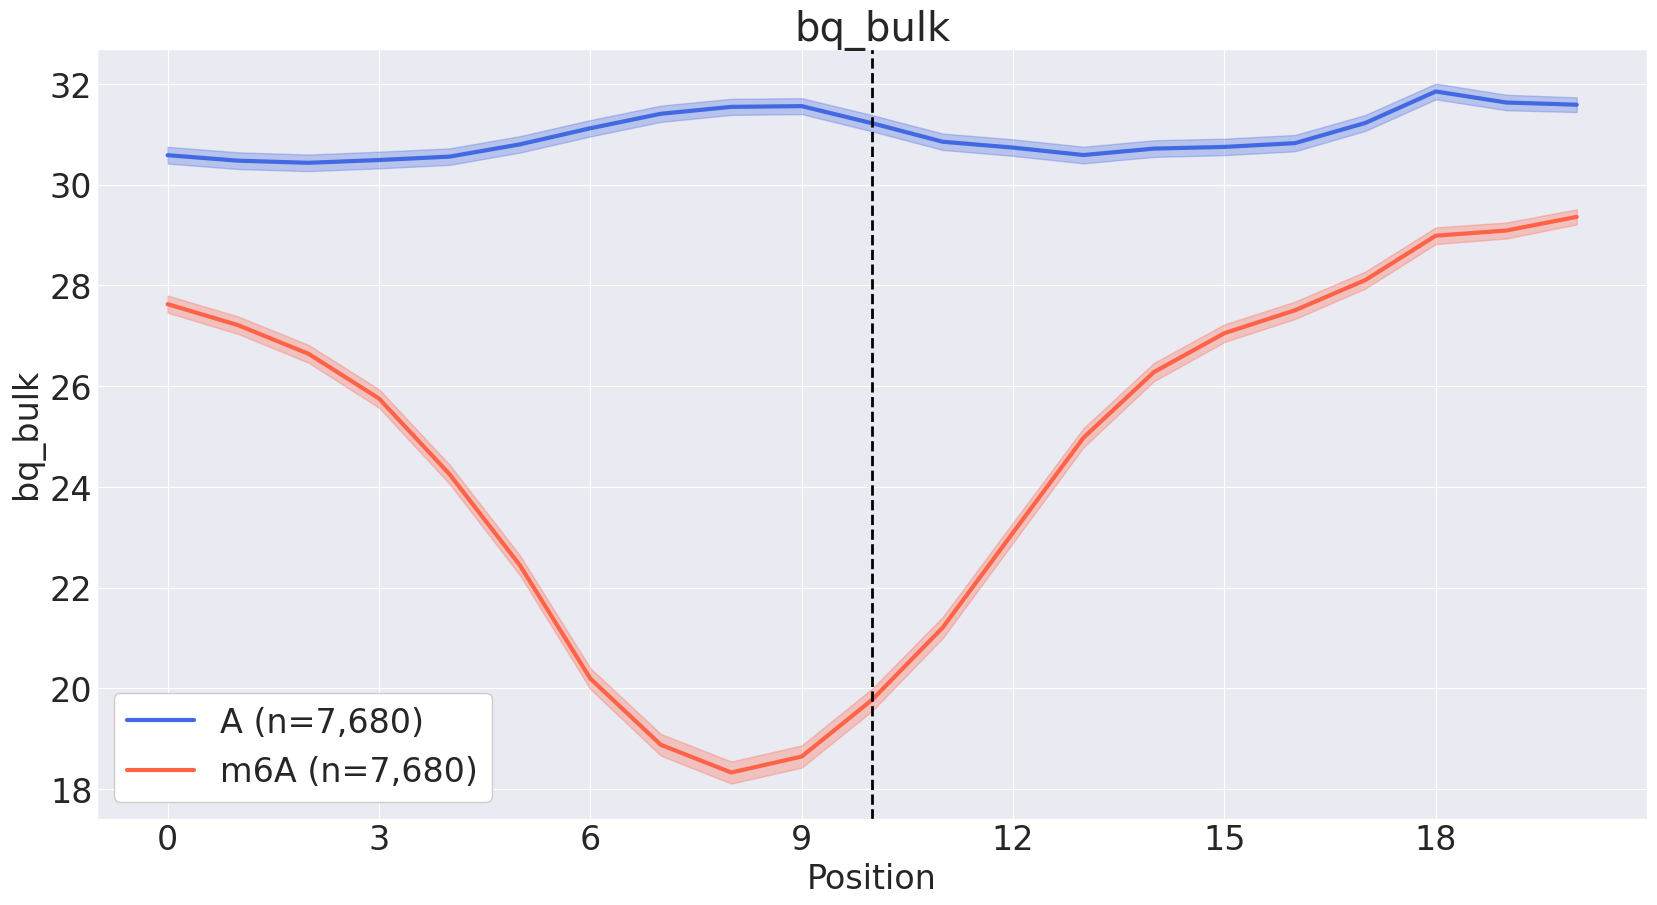

In [65]:

a_df = []
for key in ["ON0092", "ON0096"]:
    df = df_dict[key]
    df = df.groupby("5mer")
    for _, sub_df in tqdm.tqdm(df, total=df.ngroups):
        a_df.append(sub_df.sample(15))
a_df = pd.concat(a_df).copy().reset_index(drop=True)

m6a_df = []
for key in ["ON0093", "ON0098", "ON0099"]:
    df = df_dict[key]
    df = df.groupby("5mer")
    for _, sub_df in tqdm.tqdm(df, total=df.ngroups):
        m6a_df.append(sub_df.sample(10))
m6a_df = pd.concat(m6a_df).copy().reset_index(drop=True)

df_dict_2 = {"A": a_df,
             "m6A": m6a_df}

print(a_df)
print(m6a_df)

out_path = "/extdata4/baeklab/Hyeonseo/m6A/poster"

for feature in ["bq"]:
    feature_renamed = f"{feature}_bulk"
    df_dict_motif = {df_name: df for df_name, df in df_dict_2.items()}
    data_dict = {df_name: np.stack(df[feature].values) for df_name, df in df_dict_motif.items()}
    mean_dict = {df_name: np.mean(data, axis=0) for df_name, data in data_dict.items()}
    ci95_dict = {df_name: 1.96*np.std(data, axis=0)/np.sqrt(data.shape[0]) for df_name, data in data_dict.items()}
    length_dict = {df_name: data.shape[0] for df_name, data in data_dict.items()}
    lineplot(mean_dict, ci95_dict, length_dict, feature_renamed, out_path)



{'A': array([[0.93690425, 0.93690425, 0.99800473, ..., 0.9996838 , 0.9994988 ,
        0.999369  ],
       [0.9987411 , 0.99498814, 0.9800474 , ..., 0.9997488 , 0.9997488 ,
        0.9996838 ],
       [0.99498814, 0.93690425, 0.84151065, ..., 0.99369043, 0.9920567 ,
        0.9920567 ],
       ...,
       [0.9996019 , 0.9994988 , 0.9996019 , ..., 0.9998005 , 0.9996838 ,
        0.9996838 ],
       [0.999     , 0.9994988 , 0.9998415 , ..., 0.9997488 , 0.9997488 ,
        0.9996838 ],
       [0.999     , 0.9996019 , 0.9996019 , ..., 0.999369  , 0.99920565,
        0.999     ]], dtype=float32), 'm6A': array([[0.9998005 , 0.9997488 , 0.9997488 , ..., 0.9987411 , 0.99601895,
        0.99601895],
       [0.99683774, 0.99      , 0.9800474 , ..., 0.999369  , 0.9996838 ,
        0.9996019 ],
       [0.9920567 , 0.9874107 , 0.9601893 , ..., 0.999     , 0.999     ,
        0.999     ],
       ...,
       [0.999     , 0.99920565, 0.99920565, ..., 0.92056715, 0.9800474 ,
        0.99498814],
      

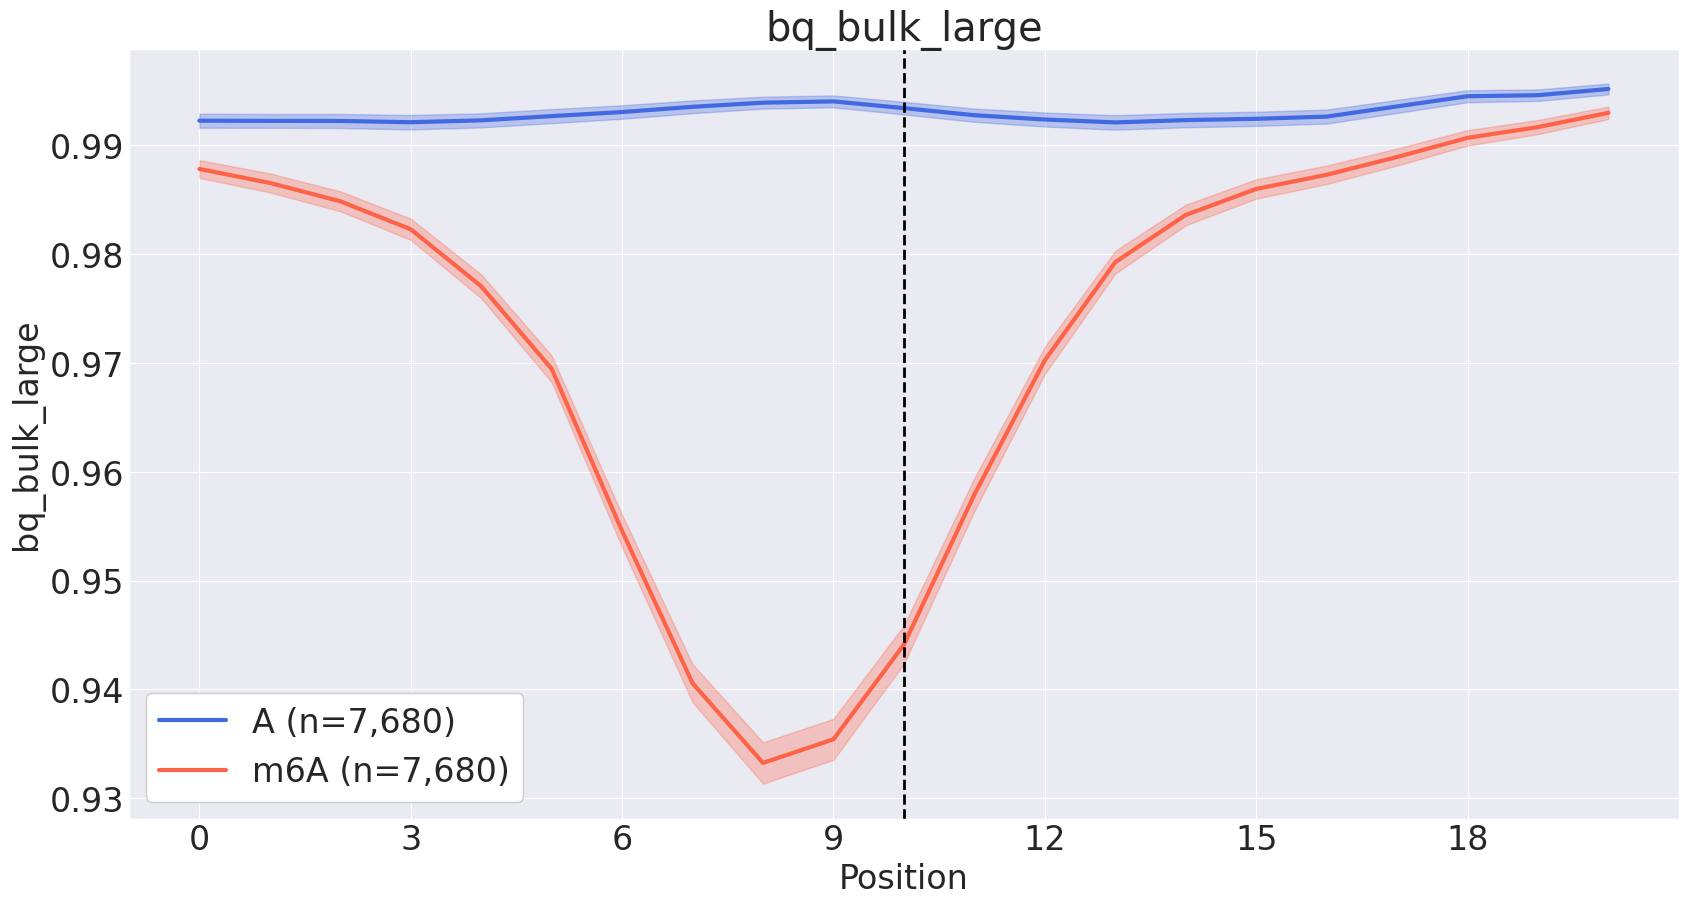

In [66]:
out_path = "/extdata4/baeklab/Hyeonseo/m6A/poster"

for feature in ["bq"]:
    feature_renamed = f"{feature}_bulk_large"
    df_dict_motif = {df_name: df for df_name, df in df_dict_2.items()}
    
    data_dict = {df_name: 1-10**(-np.stack(df[feature].values).astype(np.float32)/10) for df_name, df in df_dict_motif.items()}
    
    print(data_dict)
    mean_dict = {df_name: np.mean(data, axis=0) for df_name, data in data_dict.items()}
    ci95_dict = {df_name: 1.96*np.std(data, axis=0)/np.sqrt(data.shape[0]) for df_name, data in data_dict.items()}
    length_dict = {df_name: data.shape[0] for df_name, data in data_dict.items()}
    lineplot(mean_dict, ci95_dict, length_dict, feature_renamed, out_path)
